# Cairo Real Estate — Exploratory Data Analysis Notebook
**Author:** Marwan Ashraf  
**Last updated:** 5/20/2026 <br>
**Purpose:** Exploratory Data Analysis to get to know the cairo relastate market

In [5]:
import pandas as pd 
import numpy as np 
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy 
import plotly.graph_objects as go
from ipywidgets import widgets
from IPython.display import display
import yaml

In [2]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [3]:
df = pd.read_parquet(config['data_source']['file_paths']['cleaned_dataset'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76520 entries, 0 to 76519
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76518 non-null  string        
 1   city                         76520 non-null  string        
 2   district                     76520 non-null  string        
 3   area                         69955 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                76520 non-null  string        
 6   sale_or_rent                 76520 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76520 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76520 non-null  Int64         
 11  bathrooms                    76520 non-nu

In [11]:
df.columns

Index(['title', 'city', 'district', 'area', 'neighborhood', 'property_type',
       'sale_or_rent', 'price', 'seller_name', 'property_subtype', 'bedrooms',
       'bathrooms', 'purpose', 'ownership', 'payment option', 'furnished',
       'completion status', 'delivery term', 'deposit', 'insurance',
       'rental frequency', 'electricity meter', 'water meter',
       'covered parking', 'natural gas', 'security', 'pets allowed', 'balcony',
       'private garden', 'pool', 'landline', 'maids room',
       'built in kitchen appliances', 'elevator', 'central a/c & heating',
       'listing_date', 'area (m²)', 'level_clean'],
      dtype='object')

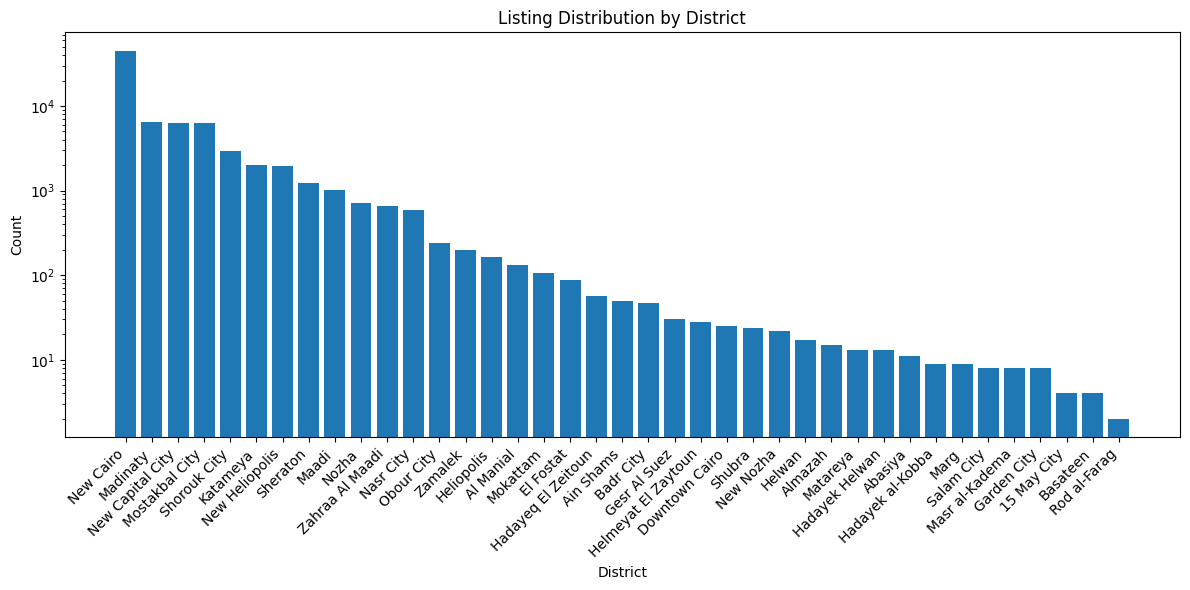

In [6]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
counts = df['district'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(counts.index, counts.values)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.xlabel('District')
plt.ylabel('Count')
plt.title('Listing Distribution by District')
plt.tight_layout()
plt.show()

In [23]:
## The data is mostly skewed in the new places this is normal because the source of our scraping advertiser/realstate agencies 
## heavly invest in new district compared to already populated districts 


In [12]:
import plotly.graph_objects as go

simple_cols = ['district','property_type',
       'sale_or_rent', 'seller_name', 'property_subtype', 'bedrooms',
       'bathrooms', 'purpose', 'ownership', 'payment option', 'furnished',
       'completion status', 'rental frequency', 'electricity meter', 'water meter',
       'covered parking', 'natural gas', 'security', 'pets allowed', 'balcony',
       'private garden', 'pool', 'landline', 'maids room',
       'built in kitchen appliances', 'elevator', 'central a/c & heating'
       , 'area (m²)', 'level_clean']
geo_cols    = ['area', 'neighborhood']
all_cols    = simple_cols + geo_cols

traces  = []
buttons = []

for i, col in enumerate(all_cols):
    counts = df[col].value_counts(ascending=False)
    traces.append(go.Bar(
        x=counts.index.astype(str),
        y=counts.values,
        name=col,
        visible=(i == 0)
    ))
    visibility = [j == i for j in range(len(all_cols))]
    buttons.append(dict(
        label=col,
        method='update',
        args=[{'visible': visibility},
              {'title': f'Distribution by {col}', 'xaxis.title.text': col}]
    ))

fig = go.Figure(data=traces)
fig.update_layout(
    title=f'Distribution by {all_cols[0]}',
    xaxis_title=all_cols[0],
    yaxis_title='Count',
    yaxis_type='log',
    width=900, height=500,
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction='down',
        x=0.0, xanchor='left',
        y=1.15, yanchor='top'
    )]
)

fig.show()

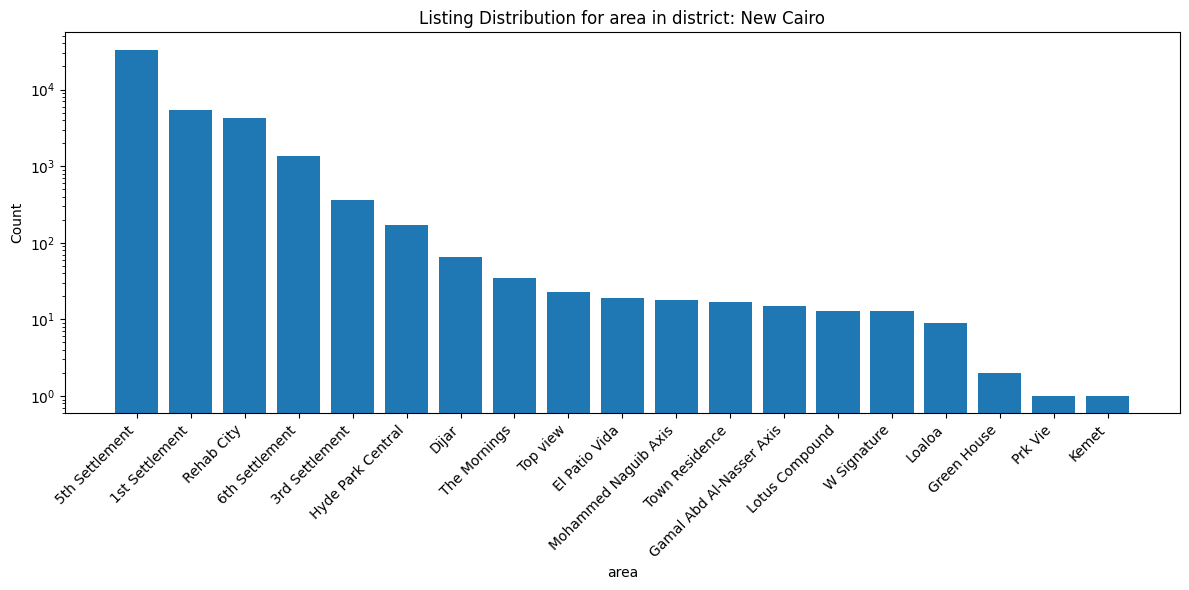

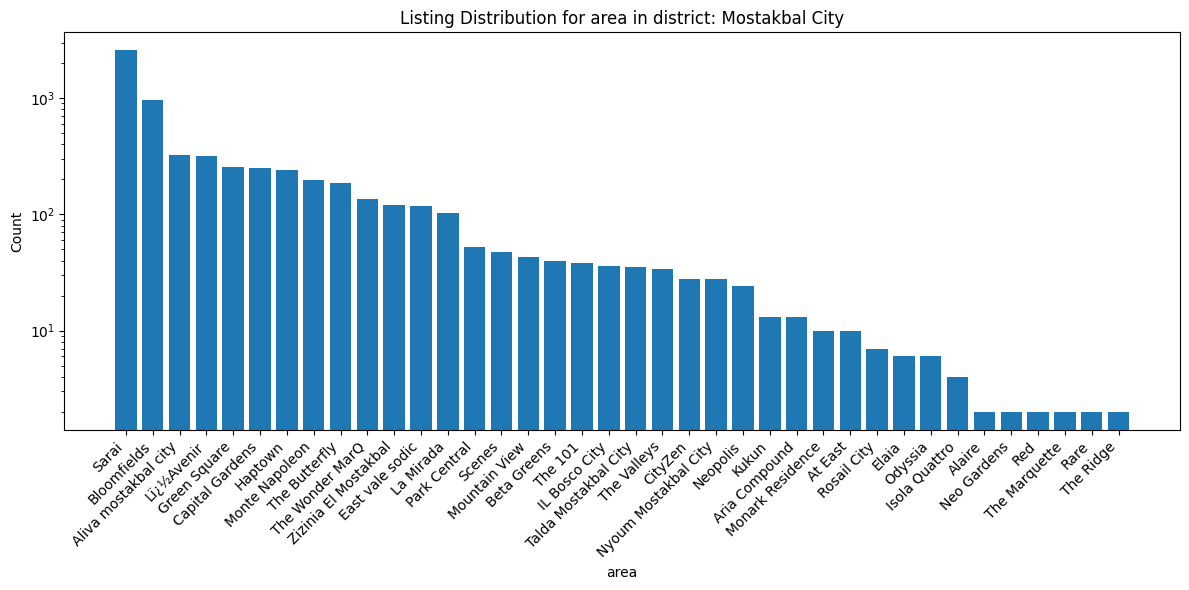

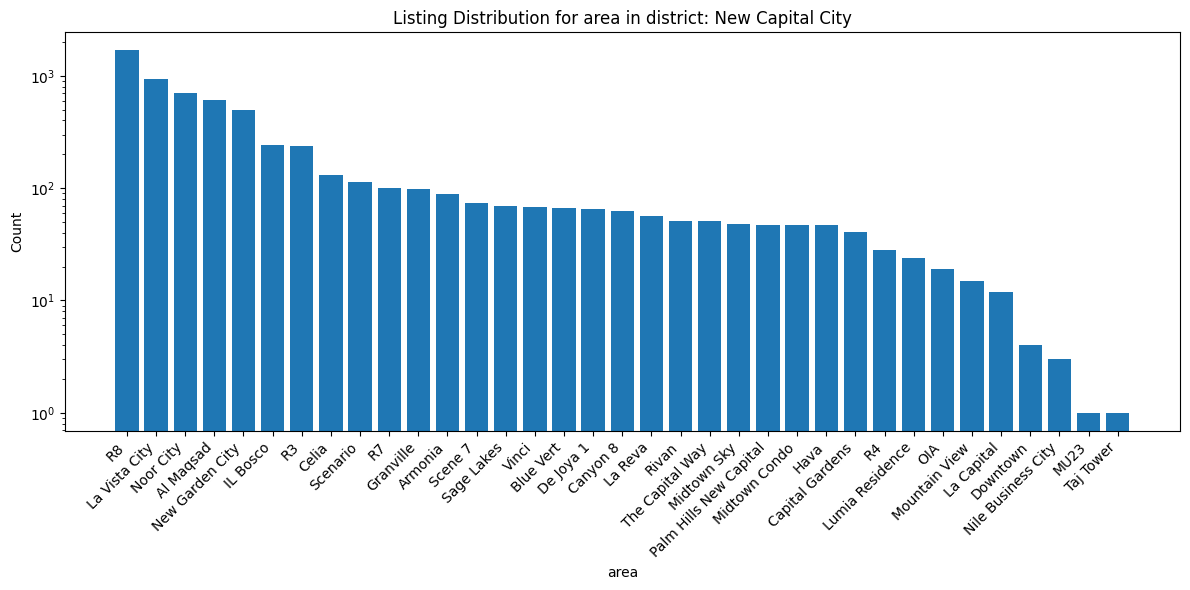

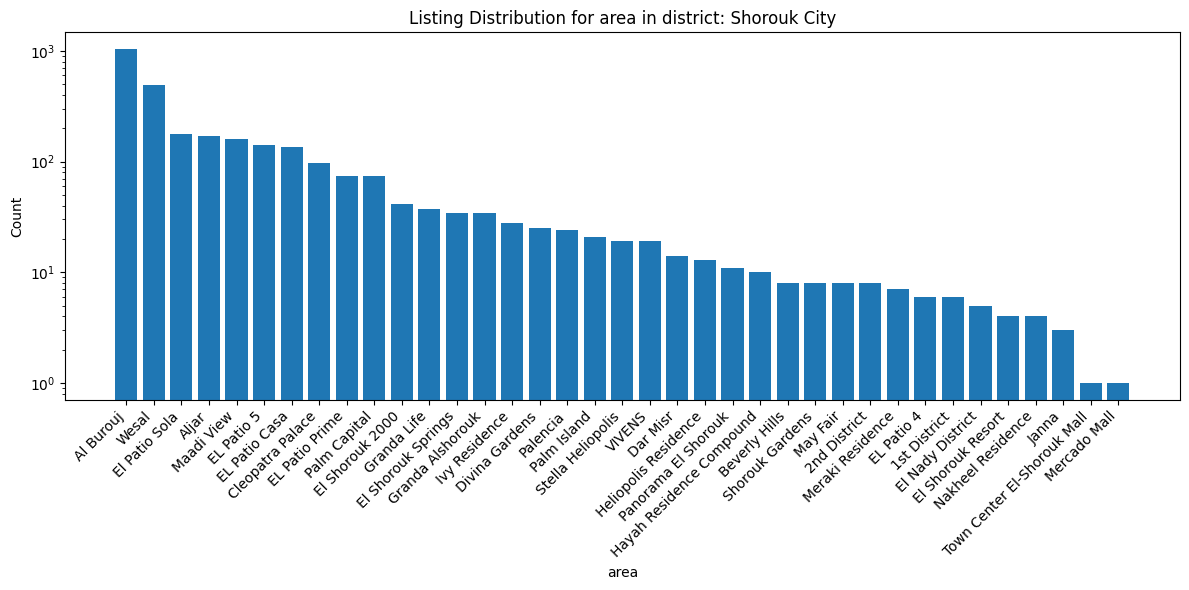

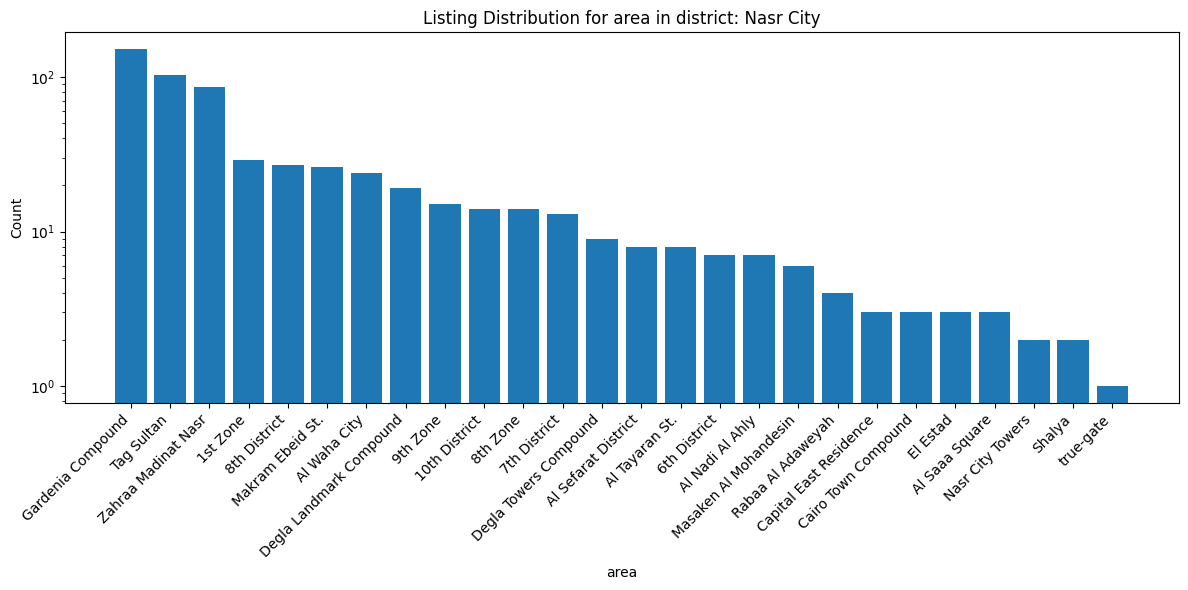

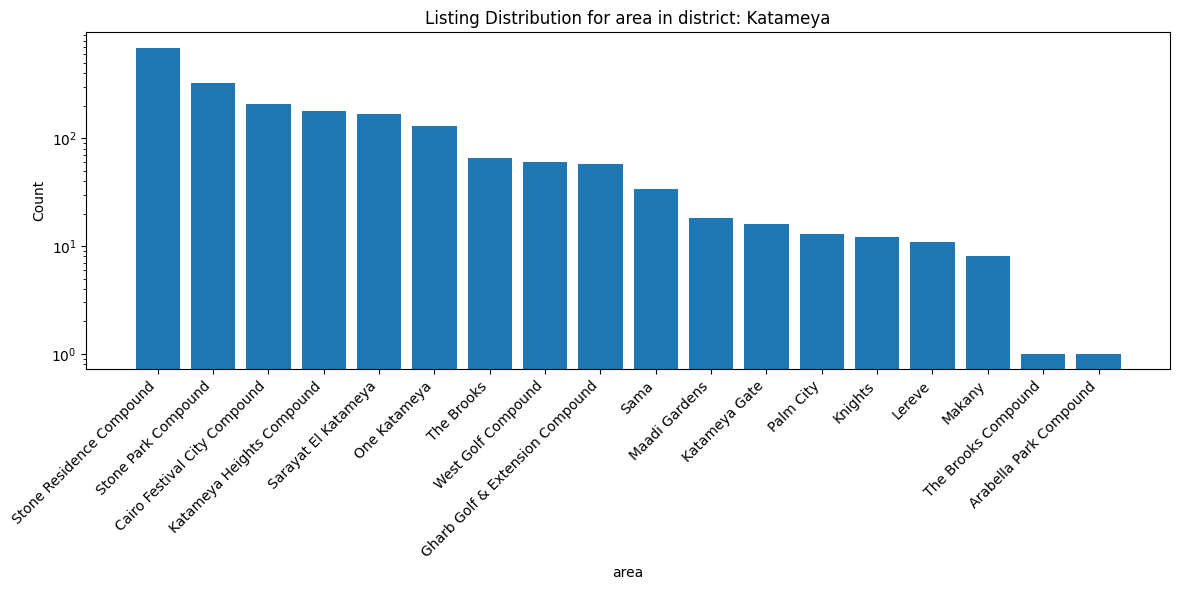

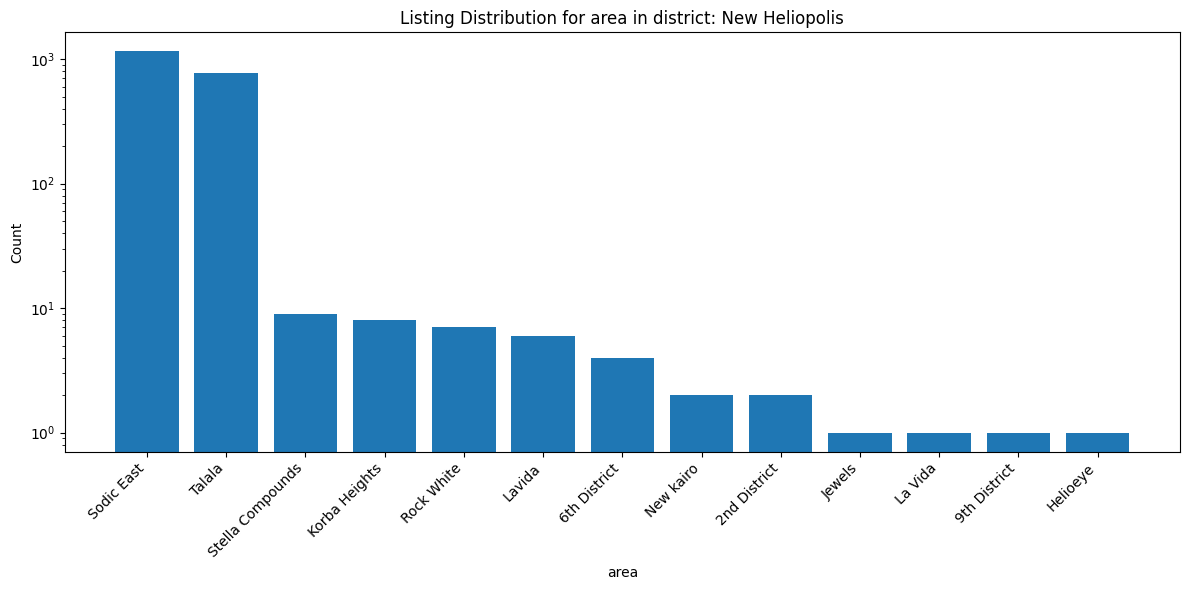

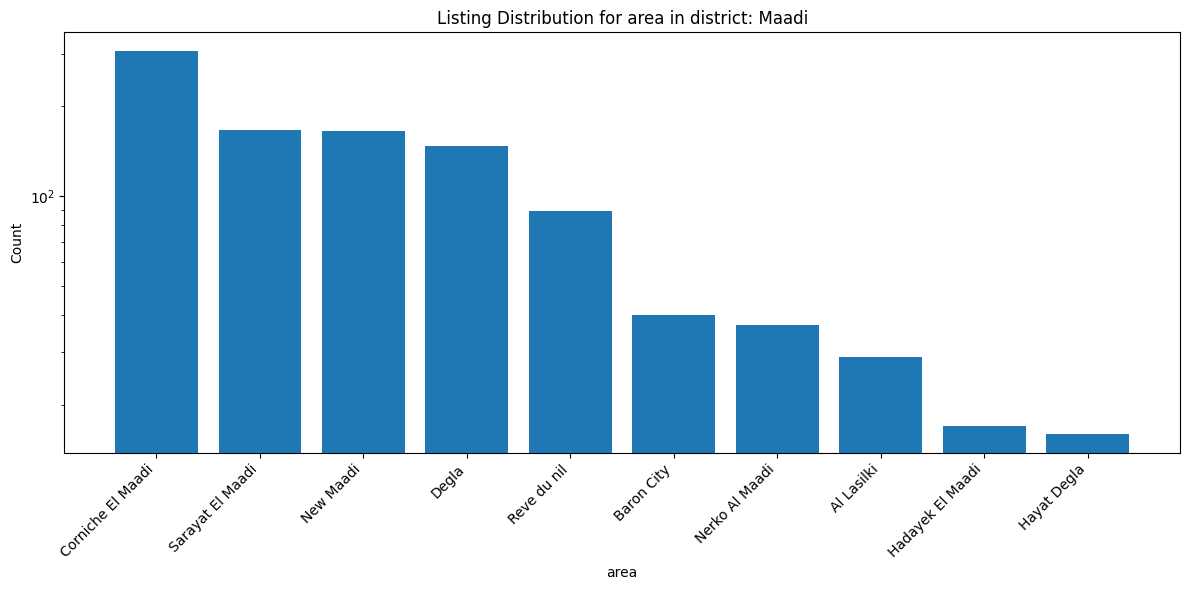

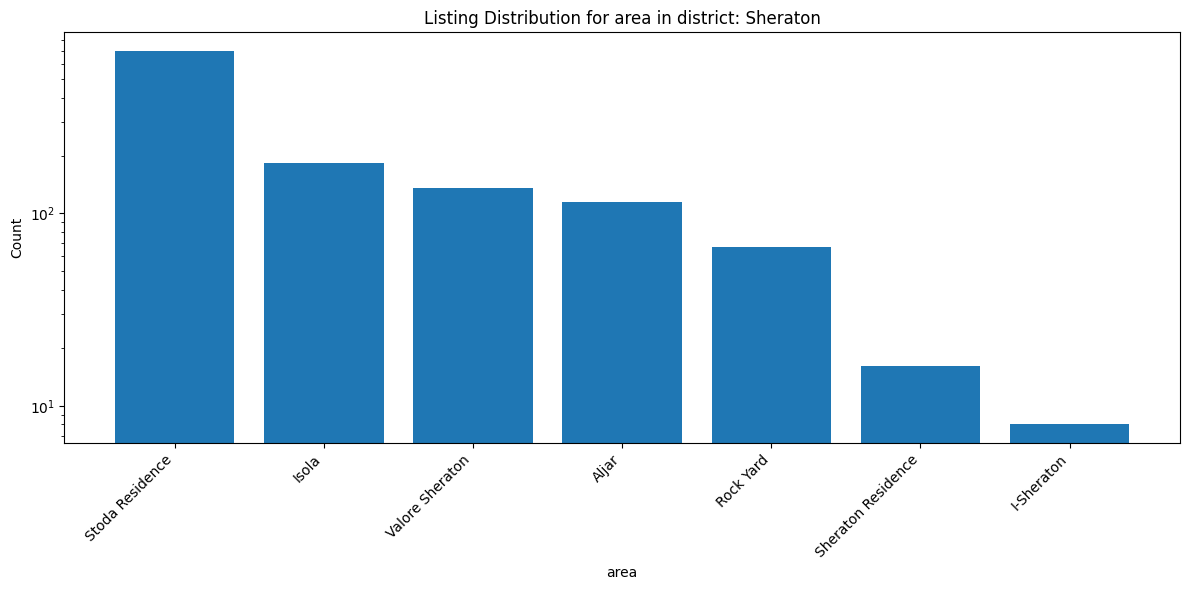

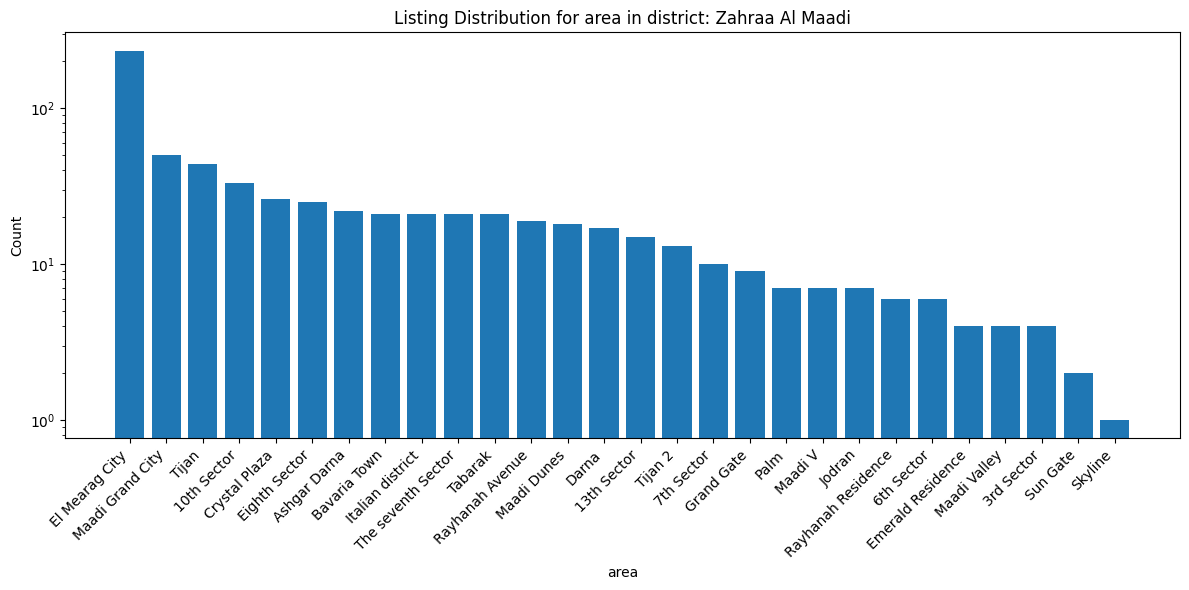

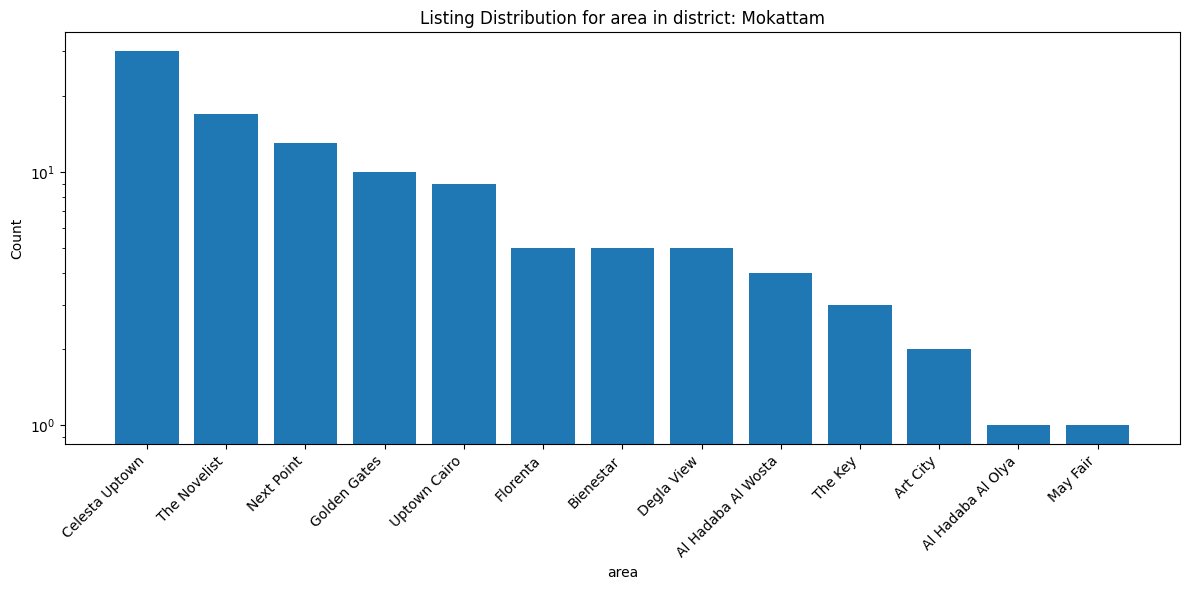

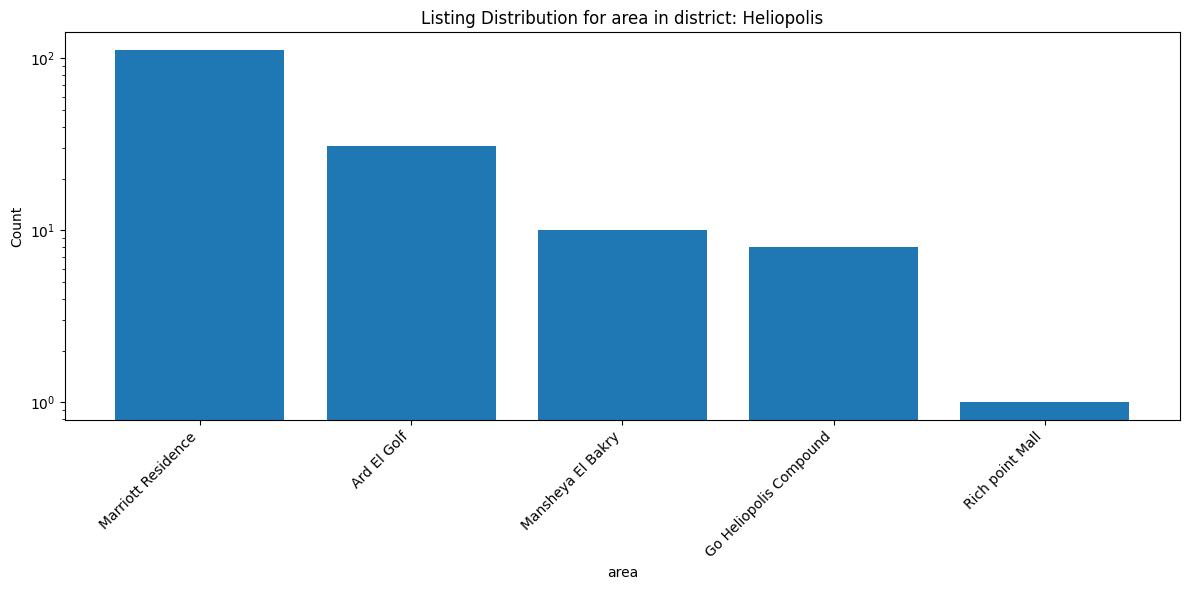

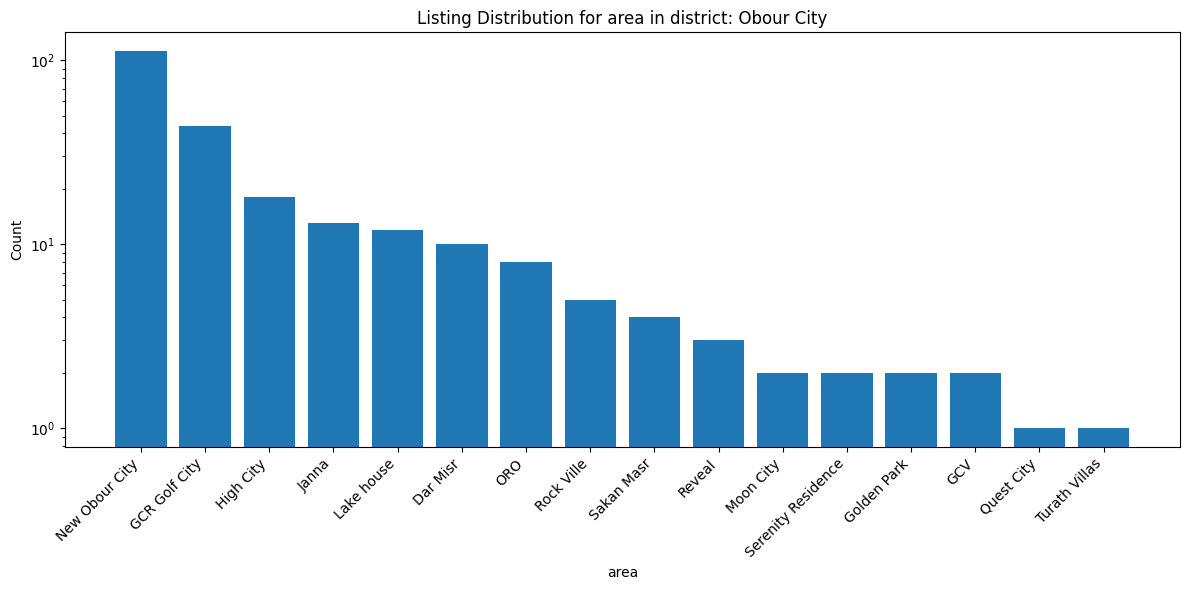

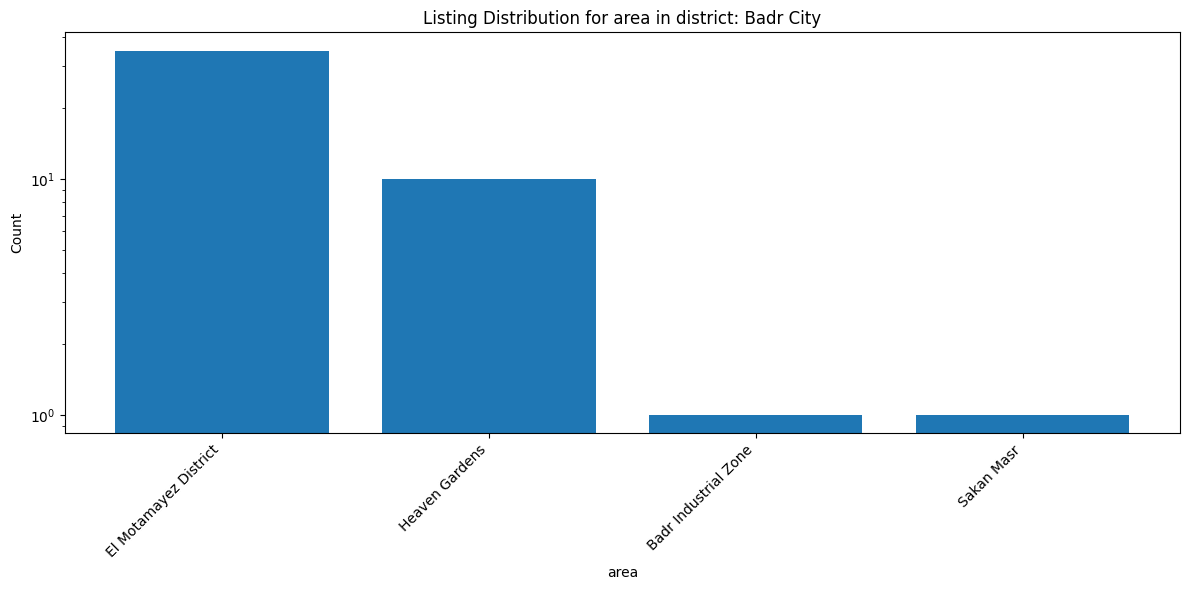

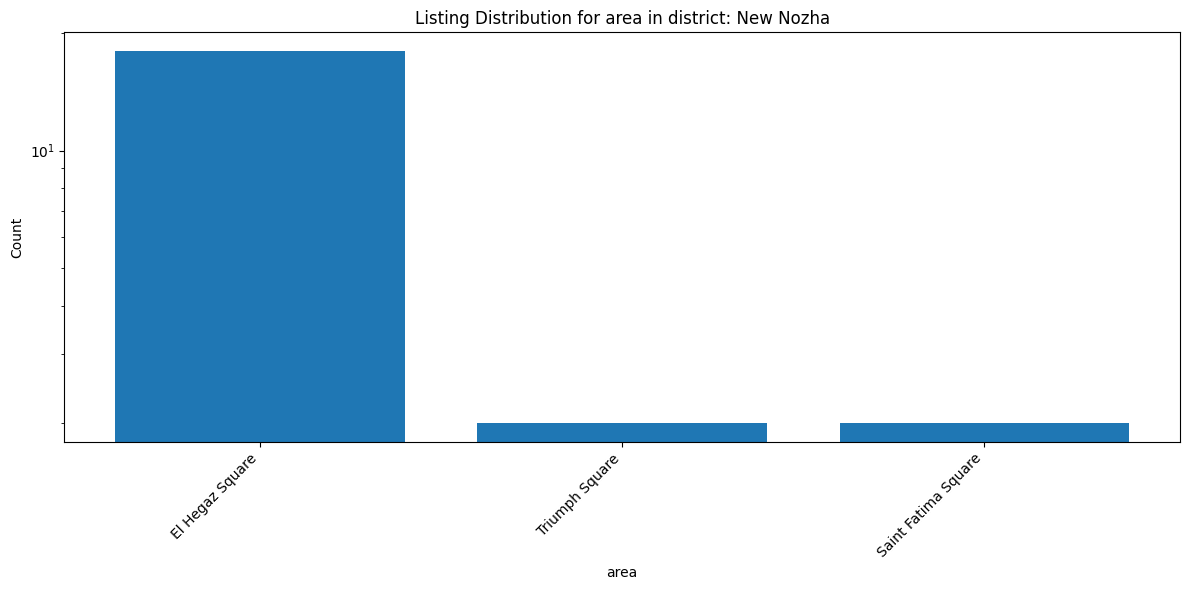

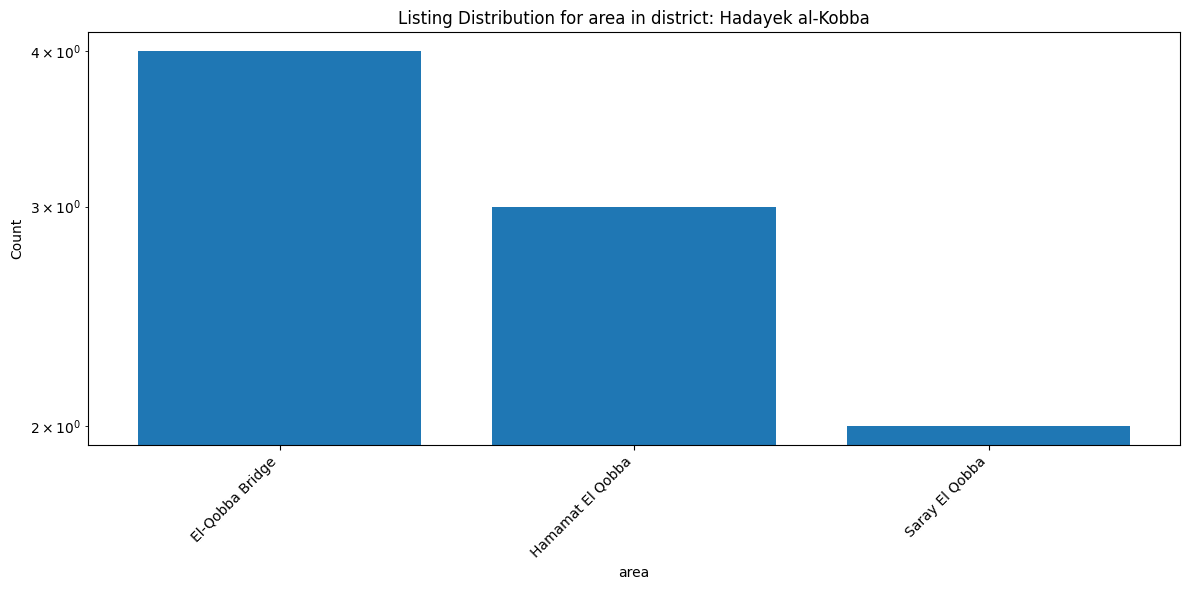

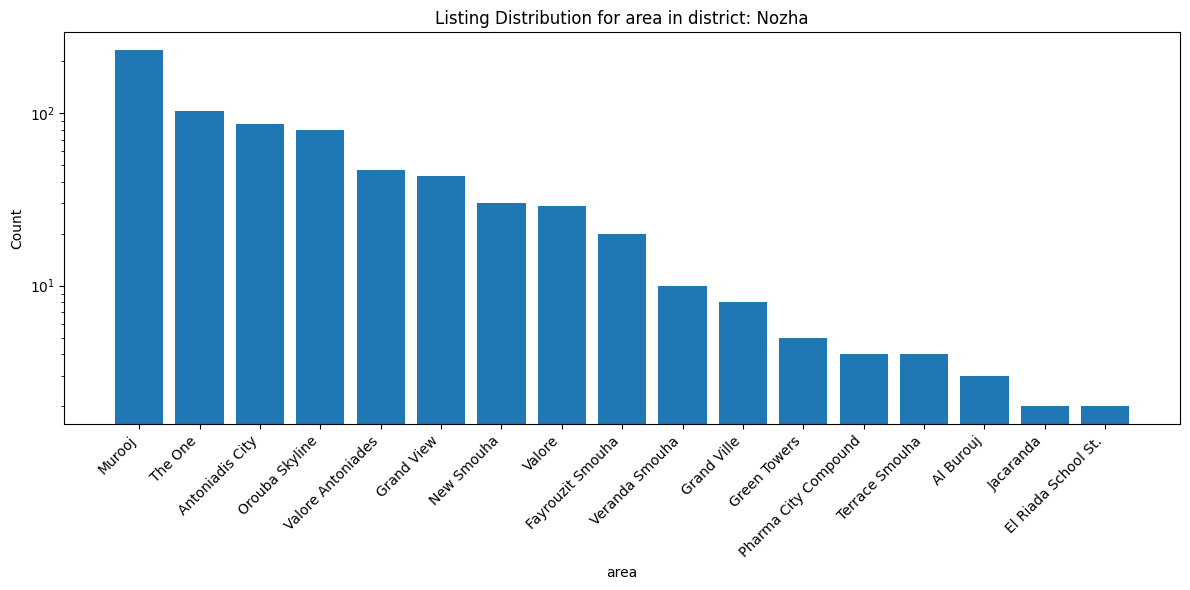

In [6]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
districts = df['district'].unique()
for district in districts:
    data = df[df['district'] == district]
    if len(data['area'].unique()) > 2: 
        counts = data['area'].value_counts()

        plt.figure(figsize=(12, 6))
        plt.bar(counts.index, counts.values)
        plt.yscale('log')
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('area')
        plt.ylabel('Count')
        plt.title(f'Listing Distribution for area in district: {district}')
        plt.tight_layout()
        plt.show()
    

In [ ]:
areas = df['area'].unique()
for area in areas:
    print(df[df['area'] == area]['neighborhood'].unique())

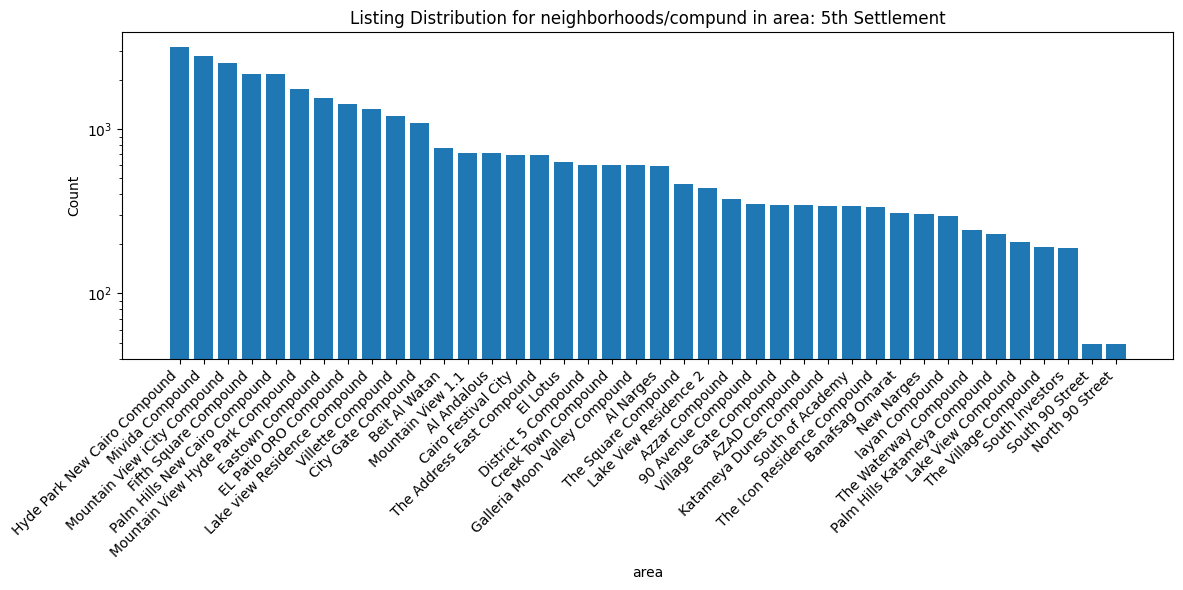

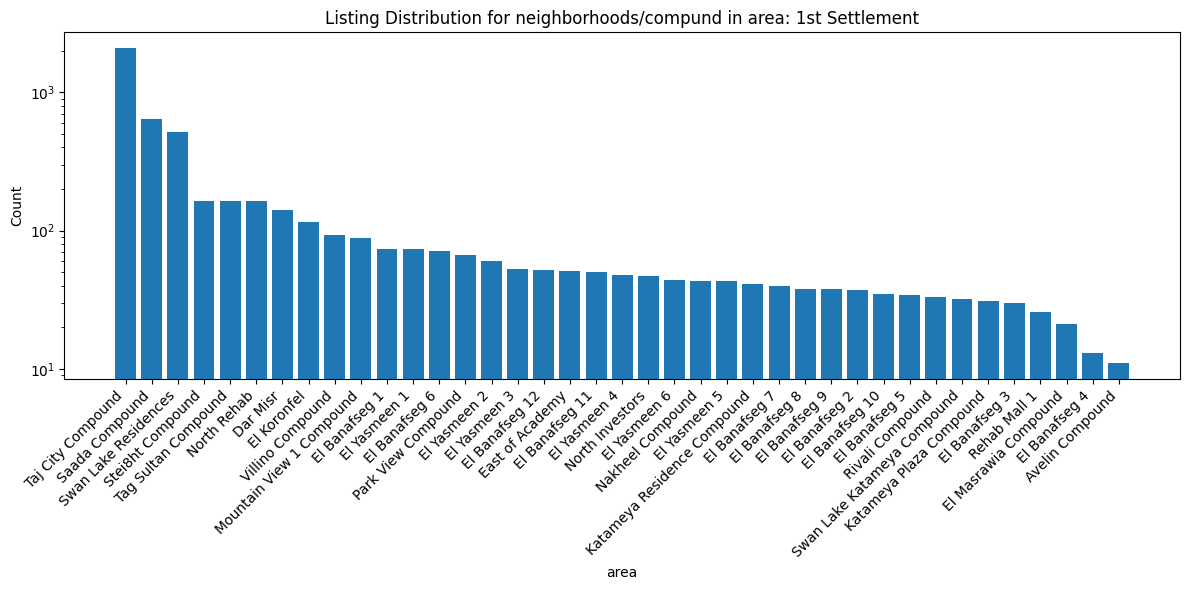

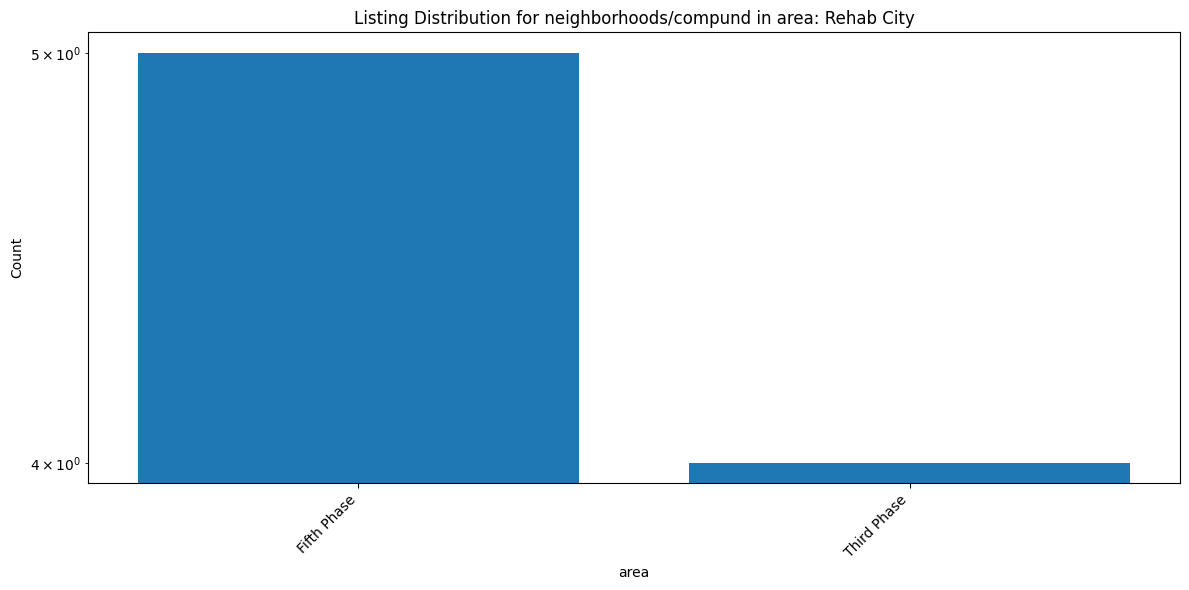

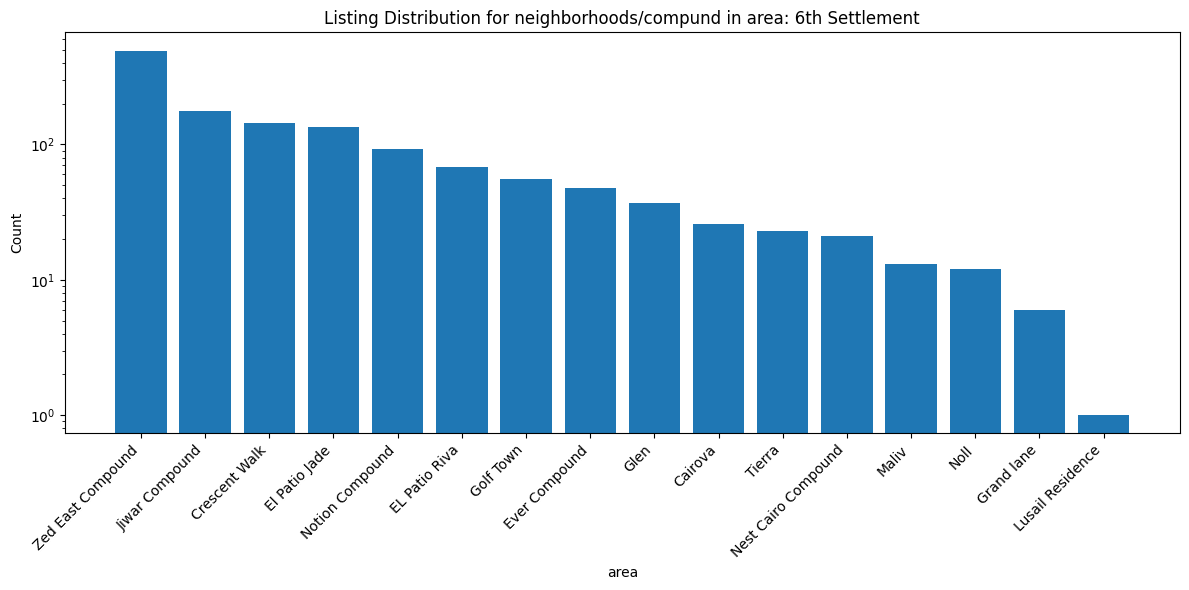

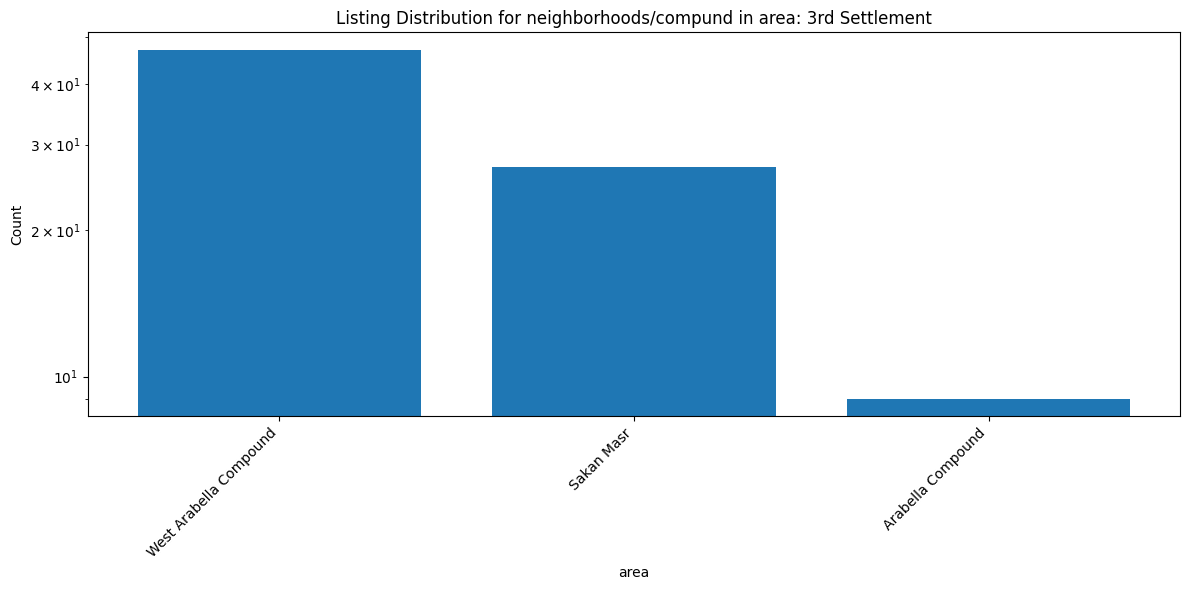

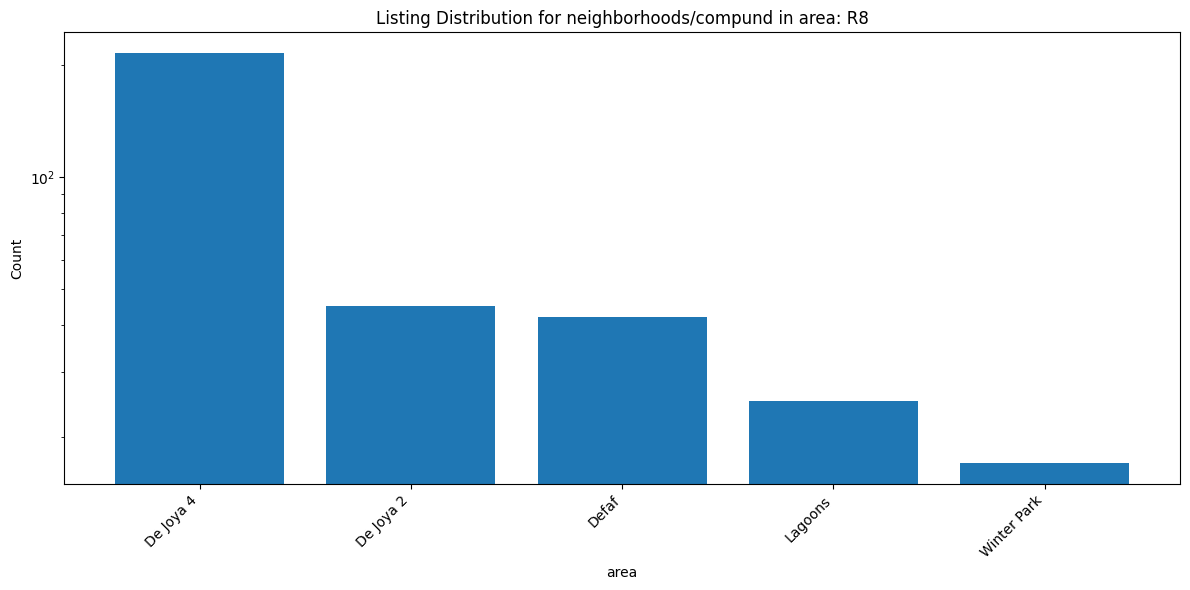

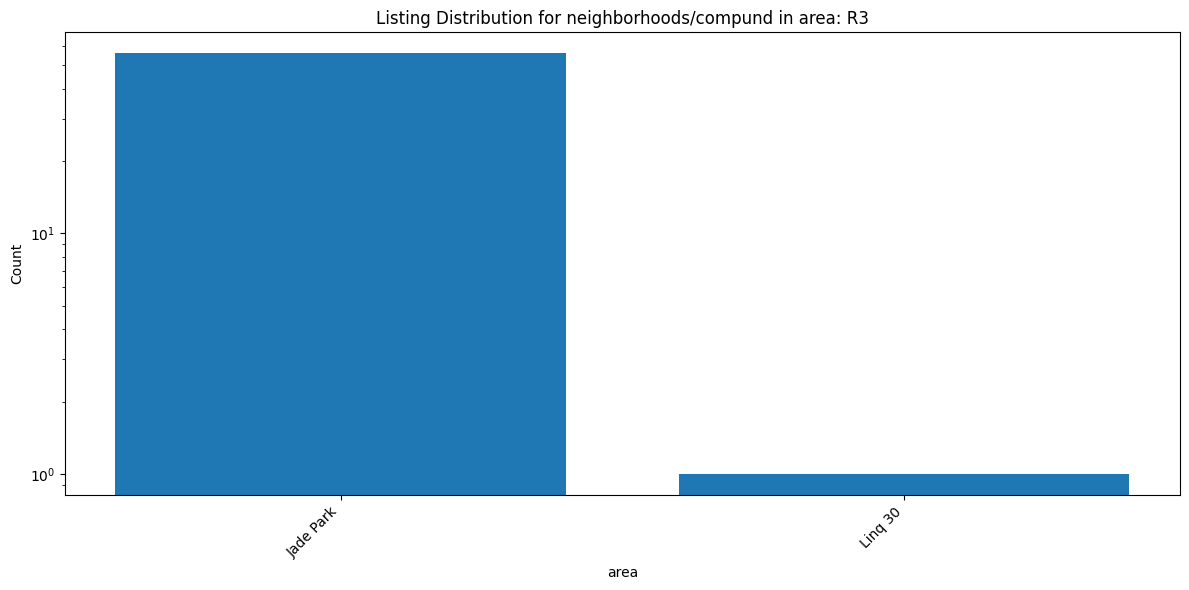

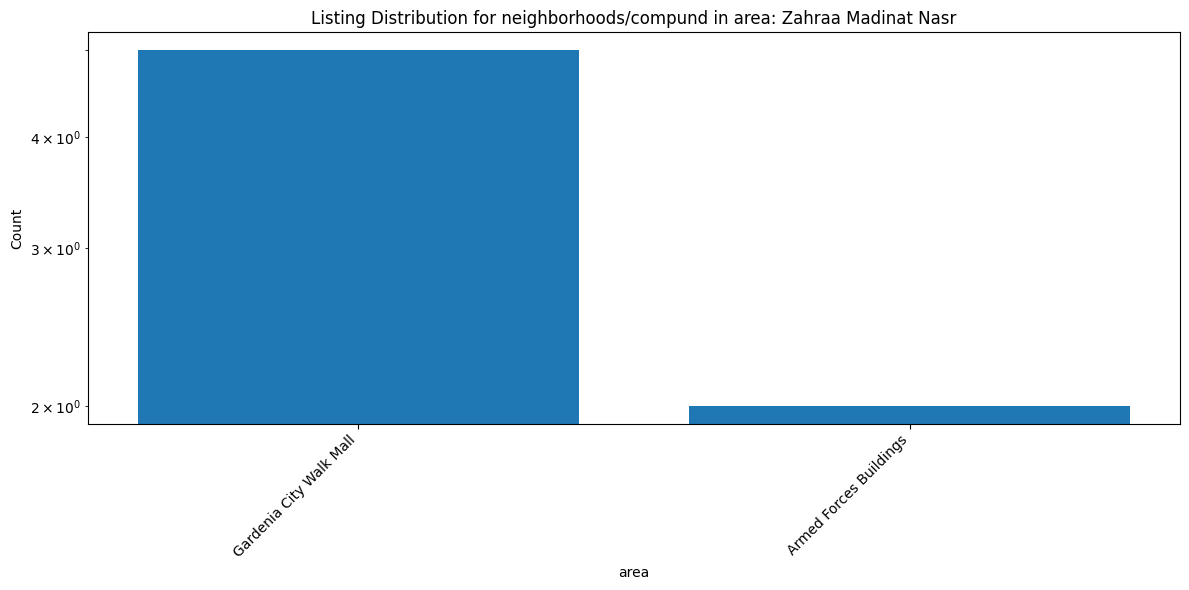

In [7]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
districts = df['district'].unique()
for district in districts:
    data = df[df['district'] == district]
    if len(data['area'].unique()) > 2: 
        areas = data['area'].unique()
        for area in areas:
            niegbhorhoods = data[data['area'] == area]['neighborhood'].unique()
            if len(niegbhorhoods ) > 1:

                counts = data[data['area'] == area]['neighborhood'].value_counts()

                plt.figure(figsize=(12, 6))
                plt.bar(counts.index, counts.values)
                plt.yscale('log')
                plt.xticks(rotation=45, ha='right')
                plt.xlabel('area')
                plt.ylabel('Count')
                plt.title(f'Listing Distribution for neighborhoods/compund in area: {area}')
                plt.tight_layout()
                plt.show()
        

In [ ]:
## This made me realease that some areas doesn't need the neighborhood level as there are lists that are on the area level that are not tied to specific neighborhood 
## Like in rehab city it should contain more tha 1k properties it contains only 5. Unfortantely this could easily be handled I will just scrape the data and

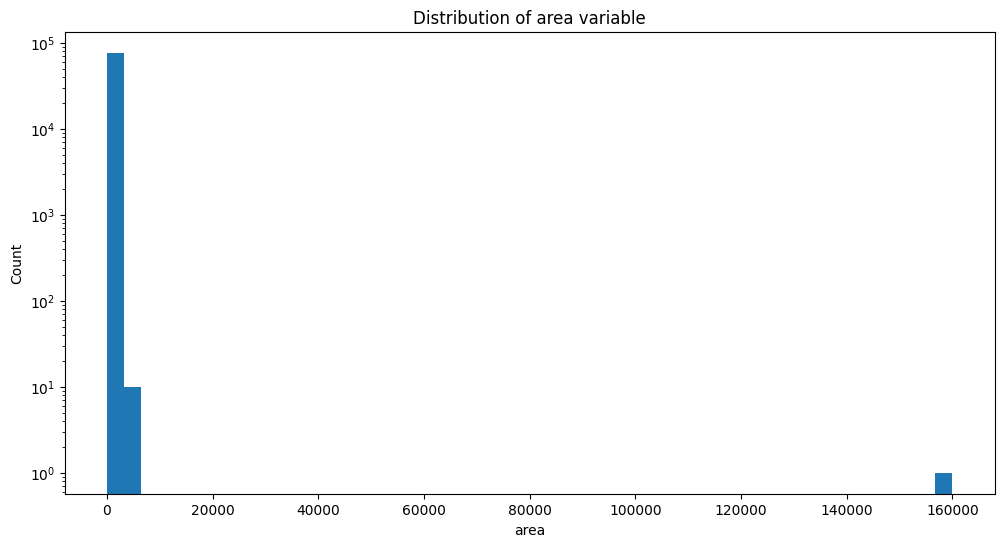

In [4]:
## Let's look at the distribution of the area varaible 
plt.figure(figsize=(12, 6))
plt.hist(df['area (m²)'], bins=50)
plt.yscale('log')
plt.xlabel('area') 
plt.ylabel('Count')
plt.title('Distribution of area variable')
plt.show()

### The area(m²) variable is very skewed and has a long tail. This is expected as there are some properties that are very large and some that are very small.
### We can see that most of the properties are between 0 and 500 m², but there are some properties that are much larger than that, which is why the distribution is skewed.

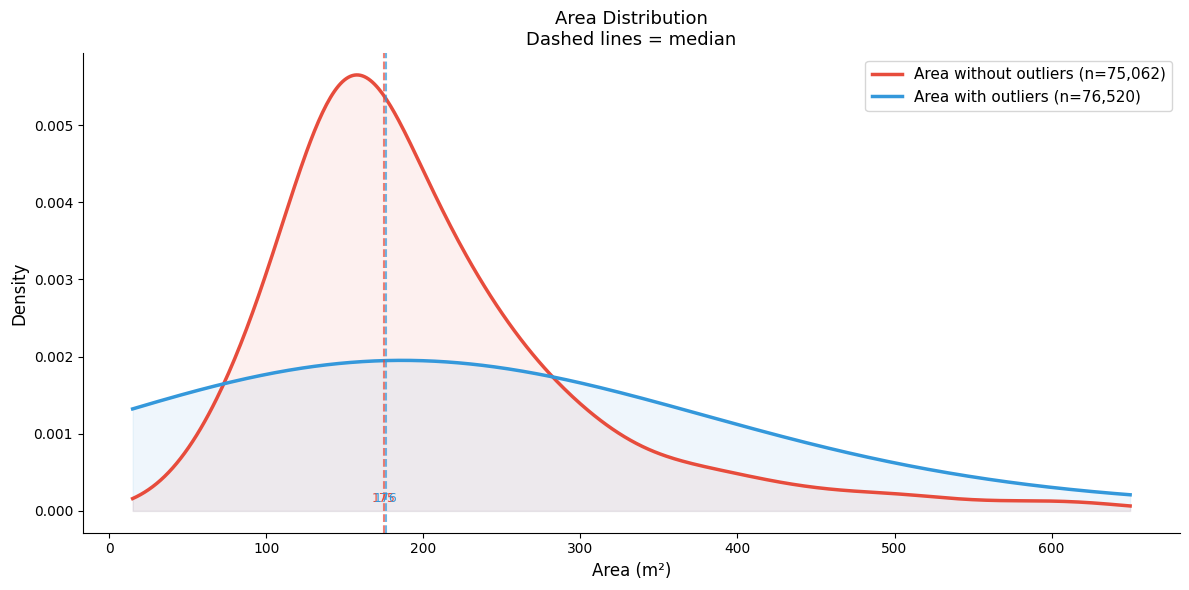

In [12]:
## A kDE will express the distribution better 


fig, ax = plt.subplots(figsize=(12, 6))

areas    = df['area (m²)'].dropna()

# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap_areas = df['area (m²)'].quantile(0.98)

sale = areas[areas <= cap_areas]


# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (sale, 'Area without outliers', '#e74c3c'),
    (areas, 'Area with outliers', '#3498db')
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap_areas, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median():.0f}', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Area (m²)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Area Distribution\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

### From the above plot we can interpert the following:
1. Most properties are concentrated around medium-sized areas (~150–200 m²), with the median staying stable even after including outliers.
2. The distribution is strongly right-skewed, meaning a small number of very large properties stretch the data toward higher values.
3. Extreme large properties have a major impact on the overall spread and variance, but they do not significantly affect the typical property size.
4. The data does not show clear multimodality overall, suggesting the market behaves as one broad distribution rather than several clearly separated groups.

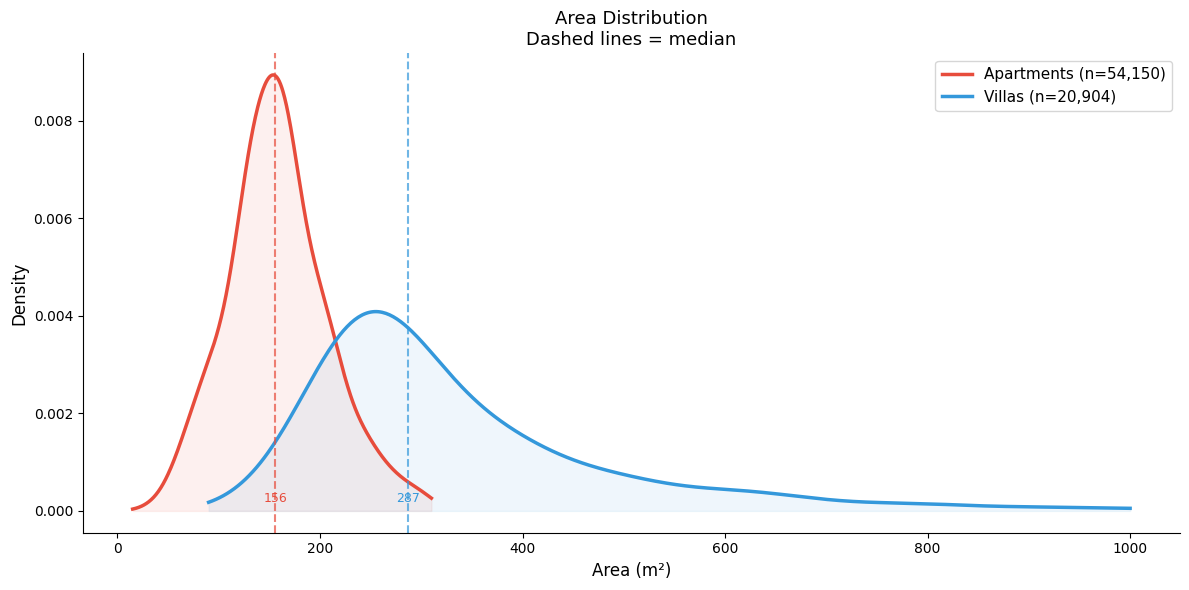

In [13]:
## A kDE will express the distribution better 


fig, ax = plt.subplots(figsize=(12, 6))

areas_ap   = df[df['property_type'] == 'apartments']['area (m²)'].dropna()
areas_villas = df[df['property_type'] == 'villas']['area (m²)'].dropna()

# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap_areas_ap = df[df['property_type'] == 'apartments']['area (m²)'].quantile(0.98)
cap_areas_villas = df[df['property_type'] == 'villas']['area (m²)'].quantile(0.98)

areas_ap = areas_ap[areas_ap <= cap_areas_ap]
areas_villas = areas_villas[areas_villas <= cap_areas_villas]

# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (areas_ap, 'Apartments', '#e74c3c'),
    (areas_villas, 'Villas', '#3498db')
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap_areas_ap if label == 'Apartments' else cap_areas_villas, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median():.0f}', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Area (m²)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Area Distribution\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

### What I can Interpret from this graph:
1. Apartments approximate a normal distribution. Villas are heavily right-skewed on their own, with a long tail extending toward 1000m².
2. Villas having high variance and a long right tail
3. There  is a notable overlap zone between 150-300m2. this indicates size alone isn't a clean separator between property types in that range.
   

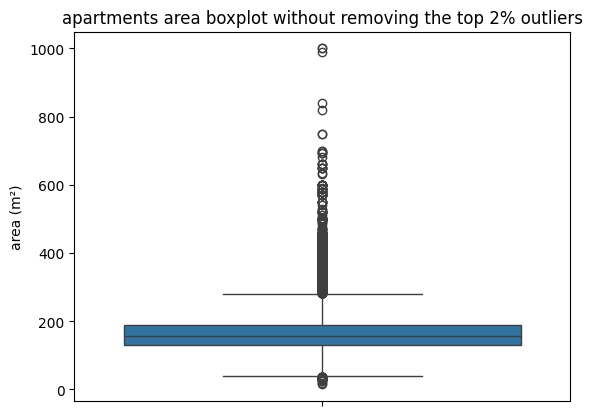

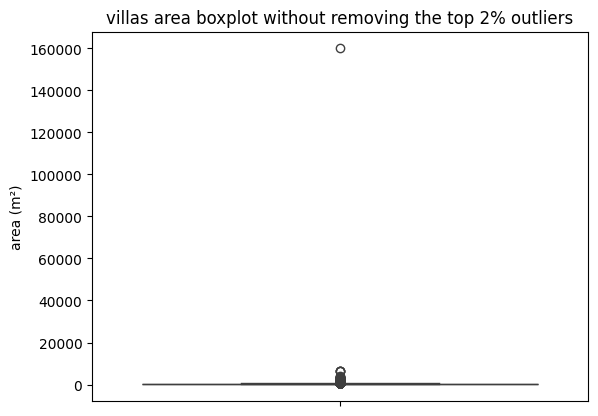

In [25]:
## Let's look at the box-plot to understand the distribution and it's sensitivity to outliers
property_type = df['property_type'].unique()
for type in property_type:

    pdata = df[df['property_type'] == type]['area (m²)']
    # pdata = pdata[pdata <= pdata.quantile(0.98)]
    sns.boxplot(pdata)
    plt.title(f'{type} area boxplot without removing the top 2% outliers')
    plt.show()

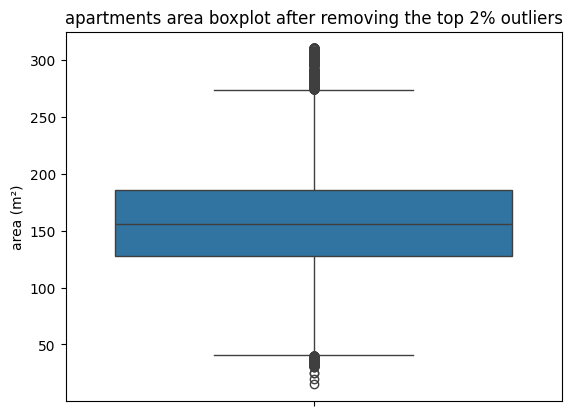

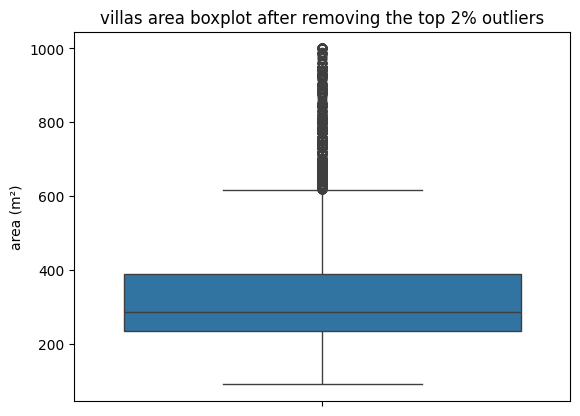

In [26]:
## Let's look at the box-plot to understand the distribution and it's sensitivity to outliers
property_type = df['property_type'].unique()
for type in property_type:

    pdata = df[df['property_type'] == type]['area (m²)']
    pdata = pdata[pdata <= pdata.quantile(0.98)]
    sns.boxplot(pdata)
    plt.title(f'{type} area boxplot after removing the top 2% outliers')
    plt.show()

**Apartments:**

- The high-area listings that look like outliers are actually legitimate — duplexes, penthouses, and full-floor apartments in Heliopolis, Maadi, and Zamalek are genuinely that large, so blindly dropping them would be a mistake.

- After removing the top 2% the core apartment market is surprisingly tight — IQR of 135–185m² — which actually makes sense given how standardized apartment construction is in Cairo.

- The area distribution looks homogeneous but it's not — `property_subtype` is what actually separates apartments from duplexes from penthouses, and each of these has its own pricing logic.

---

**Villas:**

- The raw plot is basically useless because of a single 160,000m² point that turned out to be a seller data source typo — the actual value was 160m².

- After cleaning, the distribution is right-skewed with IQR around 250–400m² and a dense cluster pushing toward 1000m² — these aren't outliers, they're large standalone villas and they're an important market segment.

- The villa category is wide — twinhouses at 100m² all the way to luxury villas at 1000m²+ — so `property_subtype` is going to do a lot of heavy lifting in the model to make sure these aren't all treated the same way.

In [29]:
outlier_apartments = df[(df['property_type'] == 'apartments') & (df[df['property_type'] == 'apartments']['area (m²)'] > df[df['property_type'] == 'apartments']['area (m²)'].quantile(0.98))]

C:\Users\marwa\AppData\Local\Temp\ipykernel_17104\2869687233.py:1: FutureWarning: Operation between Series with different indexes that are not of numpy boolean or object dtype will no longer return a numpy boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  outlier_apartments = df[(df['property_type'] == 'apartments') & (df[df['property_type'] == 'apartments']['area (m²)'] > df[df['property_type'] == 'apartments']['area (m²)'].quantile(0.98))]


In [40]:
outlier_villas = df[(df['property_type'] == 'villas') & (df[df['property_type'] == 'villas']['area (m²)'] > df[df['property_type'] == 'villas']['area (m²)'].quantile(0.98))]

C:\Users\marwa\AppData\Local\Temp\ipykernel_17104\1752750682.py:1: FutureWarning: Operation between Series with different indexes that are not of numpy boolean or object dtype will no longer return a numpy boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  outlier_villas = df[(df['property_type'] == 'villas') & (df[df['property_type'] == 'villas']['area (m²)'] > df[df['property_type'] == 'villas']['area (m²)'].quantile(0.98))]


In [41]:
outlier_villas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 403 entries, 49976 to 76519
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        402 non-null    string        
 1   city                         403 non-null    string        
 2   district                     403 non-null    string        
 3   area                         341 non-null    string        
 4   neighborhood                 261 non-null    string        
 5   property_type                403 non-null    string        
 6   sale_or_rent                 403 non-null    string        
 7   price                        403 non-null    Int64         
 8   seller_name                  403 non-null    string        
 9   property_subtype             403 non-null    string        
 10  bedrooms                     403 non-null    Int64         
 11  bathrooms                    403 non-null   

In [42]:
outlier_villas.describe()

,price,bedrooms,bathrooms,deposit,insurance,listing_date,area (m²)
count,403.0,403.0,403.0,12.0,15.0,403,403.000000
mean,119979386.672457,6.965261,7.111663,357583.333333,362333.733333,2026-04-13 11:18:54.491315200,1853.059553
min,5000.0,3.0,2.0,2000.0,2.0,2025-09-06 00:00:00,1002.000000
25%,50000000.0,5.0,6.0,237500.0,130500.0,2026-04-12 00:00:00,1100.000000
50%,85000000.0,7.0,7.0,292000.0,299000.0,2026-04-19 00:00:00,1200.000000
75%,173950000.0,8.0,9.0,400000.0,490000.0,2026-04-27 00:00:00,1600.000000
max,881000000.0,10.0,10.0,840000.0,1100000.0,2026-05-19 00:00:00,160000.000000
std,108406497.303972,1.989721,2.03329,251805.284923,315032.989808,NaN,7927.406408


In [43]:
specific_villas = outlier_villas[outlier_villas['area (m²)'] > 1400]

In [47]:
specific_villas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, 50004 to 76331
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        124 non-null    string        
 1   city                         125 non-null    string        
 2   district                     125 non-null    string        
 3   area                         124 non-null    string        
 4   neighborhood                 89 non-null     string        
 5   property_type                125 non-null    string        
 6   sale_or_rent                 125 non-null    string        
 7   price                        125 non-null    Int64         
 8   seller_name                  125 non-null    string        
 9   property_subtype             125 non-null    string        
 10  bedrooms                     125 non-null    Int64         
 11  bathrooms                    125 non-null   

In [49]:
specific_villas = specific_villas[specific_villas['area (m²)'] == specific_villas['area (m²)'].max()]

In [50]:
specific_villas.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,payment option,furnished,completion status,delivery term,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),level_clean
57738,In front of Cairo Airport and with installment over 8 years Villa in Taj City Compound,Cairo,New Cairo,1st Settlement,Taj City Compound,villas,sale,20000000,BackYard for Real estate,Stand Alone Villa,3,3,for sale,primary,cash or installment,no,off-plan,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,True,True,True,False,False,False,False,2026-04-05,160000.0,independent unit


### After looking at the data carefully and investagting with the original data source I found that this point should be 160m not 160000m. I will update a cleaned version of the dataset to fix this mistake

In [51]:
df.loc[57738, 'area (m²)'] = 160.0

In [52]:
df.to_parquet('../data/cleaned_dataset_v2.parquet', index=False)

In [53]:
### Let's continue our Analysis.

In [ ]:
specific_villas.describe()

,price,bedrooms,bathrooms,deposit,insurance,listing_date,area (m²)
count,125.0,125.0,125.0,1.0,1.0,125,125.000000
mean,184164166.296,7.632,7.856,2000.0,1000.0,2026-04-12 13:37:55.200000,3384.168000
min,5000.0,3.0,3.0,2000.0,1000.0,2026-01-03 00:00:00,1430.000000
25%,65000000.0,6.0,6.0,2000.0,1000.0,2026-04-06 00:00:00,1620.000000
50%,188000000.0,8.0,8.0,2000.0,1000.0,2026-04-19 00:00:00,1825.000000
75%,258000000.0,10.0,10.0,2000.0,1000.0,2026-04-27 00:00:00,2102.000000
max,881000000.0,10.0,10.0,2000.0,1000.0,2026-05-19 00:00:00,160000.000000
std,143631738.850624,2.168454,2.135355,<NA>,<NA>,NaN,14152.229186


In [45]:
import pandas as pd

# Show every row in the DataFrame
pd.set_option('display.max_rows', None)

# Show every column in the DataFrame
pd.set_option('display.max_columns', None)

# Show the full content within each cell (preventing long text from being cut off)
pd.set_option('display.max_colwidth', None)

# Show all items in a list inside a cell
pd.set_option('display.max_seq_items', None)


In [ ]:
# specific_villas.head(10)

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,bedrooms,bathrooms,purpose,ownership,payment option,furnished,completion status,delivery term,deposit,insurance,rental frequency,electricity meter,water meter,covered parking,natural gas,security,pets allowed,balcony,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),level_clean
50004,"VIP Palace for sale – Immediate delivery,1500 sqm in Hyde Park, New Cairo Close to Mivida, 90th Street, and AUC",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,villas,sale,44000000,Property Hills One 1,Stand Alone Villa,10,10,for sale,primary,cash,no,ready,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,False,True,True,False,False,False,False,False,2026-04-19,1500.0,independent unit
50338,"palace ready for immediate delivery in Hyde Park, Fifth Settlement",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,villas,sale,77000000,Property Hills One 1,Stand Alone Villa,8,8,for sale,primary,cash or installment,no,ready,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,True,False,True,False,True,False,False,2026-04-12,1800.0,independent unit
50376,"Palace for sale in Hyde Park Compound, Fifth Settlement",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,villas,sale,200000000,Imkan Investment,Stand Alone Villa,10,10,for sale,primary,cash or installment,no,ready,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,False,False,True,False,False,False,False,2026-04-12,1695.0,independent unit
51096,Palace 1880 + immediate delivery with a private swimming pool next to مفيدا بهايد بارك التجمع الخامس near the American University\nقصر 1880م استلام فوري بحمام سباحه خاص بجانب مفيدا بهايد بارك التجمع الخامس بالقرب من الجامعه الامريكيه,Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,villas,sale,40500000,This ad is no longer available,Stand Alone Villa,7,7,for sale,<NA>,cash,<NA>,ready,<NA>,<NA>,<NA>,<NA>,False,True,True,True,False,True,False,True,False,True,False,False,False,False,2026-04-26,1880.0,independent unit
51136,"palace ready for immediate delivery in Hyde Park, Fifth Settlement",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,villas,sale,77000000,This ad is no longer available,Stand Alone Villa,8,8,for sale,<NA>,cash or installment,no,ready,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,True,False,True,False,True,False,False,2026-04-26,1800.0,independent unit
51162,"palace ready for immediate delivery in Hyde Park, Fifth Settlement",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,villas,sale,77000000,This ad is no longer available,Stand Alone Villa,8,8,for sale,<NA>,cash or installment,no,ready,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,True,False,True,False,True,False,False,2026-04-26,1800.0,independent unit
51163,"palace ready for immediate delivery in Hyde Park, Fifth Settlement",Cairo,New Cairo,5th Settlement,Hyde Park New Cairo Compound,villas,sale,77000000,This ad is no longer available,Stand Alone Villa,8,8,for sale,<NA>,cash or installment,no,ready,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,True,False,True,False,True,False,False,2026-04-26,1800.0,independent unit
53368,two family unit villas 6 bedrooms with penthouse prime location in palm hills new cairo,Cairo,New Cairo,5th Settlement,Palm Hills New Cairo Compound,villas,sale,63500000,New Avenue,Stand Alone Villa,6,6,for sale,resale,cash,no,ready,<NA>,<NA>,<NA>,<NA>,True,True,True,True,False,True,False,True,True,False,False,False,False,False,2026-04-26,1660.0,independent unit
53498,For sale - a new villa divided into apartments in Al-Narjis neighborhood - Fifth Settlement,Cairo,New Cairo,5th Settlement,Fifth Square Compound,villas,sale,60000000,ريمكس فريست تشويس,Stand Alone Villa,10,10,for sale,resale,cash,no,ready,<NA>,<NA>,<NA>,<NA>,True,True,True,True,True,True,True,True,False,False,False,False,False,False,2

In [30]:
outlier_apartments_count = outlier_apartments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1063 entries, 1576 to 75556
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        1063 non-null   string        
 1   city                         1063 non-null   string        
 2   district                     1063 non-null   string        
 3   area                         1002 non-null   string        
 4   neighborhood                 697 non-null    string        
 5   property_type                1063 non-null   string        
 6   sale_or_rent                 1063 non-null   string        
 7   price                        1063 non-null   Int64         
 8   seller_name                  1063 non-null   string        
 9   property_subtype             1063 non-null   string        
 10  bedrooms                     1063 non-null   Int64         
 11  bathrooms                    1063 non-null  

In [31]:
outlier_apartments.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,...,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),level_clean
1576,FOR SALE READY TO MOVE FULLY FINISHED VILLA IN...,Cairo,New Cairo,5th Settlement,Mivida Compound,apartments,sale,40000000,Egypt Best Properties (EBP,Duplex,...,True,True,True,True,True,False,True,2026-04-08,501.0,<NA>
3493,Park villa duplex with garden for sale in Moun...,Cairo,New Cairo,5th Settlement,Mountain View iCity Compound,apartments,sale,12000000,This ad is no longer available,Duplex,...,True,False,True,False,False,False,False,2026-04-29,325.0,<NA>
4848,"Penthouse for sale in Al Marasem compound, fur...",Cairo,New Cairo,5th Settlement,Fifth Square Compound,apartments,sale,10000000,EGY REALTY INVESTMENT,Penthouse,...,True,True,True,True,True,True,True,2026-04-23,343.0,top
5148,Prime penthouse for sale in fifth square,Cairo,New Cairo,5th Settlement,Fifth Square Compound,apartments,sale,27200000,NCH,Penthouse,...,True,True,True,True,True,False,False,2026-04-15,340.0,top
5225,Resale 205m Ready With AC's & Kitchen Garden a...,Cairo,New Cairo,5th Settlement,Fifth Square Compound,apartments,sale,16500000,GHP,Apartment,...,False,False,False,True,False,False,False,2026-04-15,356.0,<NA>


In [36]:
apart = outlier_apartments[outlier_apartments['property_subtype'] == 'Apartment']

In [37]:
apart.describe()

,price,bedrooms,bathrooms,deposit,insurance,listing_date,area (m²)
count,402.0,402.0,402.0,41.0,43.0,402,402.000000
mean,11363380.925373,3.935323,3.472637,125341.463415,90535.0,2026-04-16 00:32:14.328358144,381.427861
min,8500.0,1.0,1.0,1000.0,1.0,2025-11-03 00:00:00,312.000000
25%,120000.0,3.0,3.0,40000.0,39000.0,2026-04-10 00:00:00,330.000000
50%,9500000.0,4.0,3.0,55000.0,80000.0,2026-04-17 00:00:00,350.000000
75%,15438500.0,4.0,4.0,100000.0,105000.0,2026-04-25 00:00:00,400.000000
max,225500000.0,9.0,7.0,1620000.0,320000.0,2026-05-21 00:00:00,820.000000
std,17012401.100248,1.062062,0.947762,253283.695661,76102.342173,NaN,76.832240


In [39]:
max_apart = apart[apart['area (m²)'] == apart['area (m²)'].max()]
max_apart.head()

,title,city,district,area,neighborhood,property_type,sale_or_rent,price,seller_name,property_subtype,...,private garden,pool,landline,maids room,built in kitchen appliances,elevator,central a/c & heating,listing_date,area (m²),level_clean
34234,شقة 820 م صف اول علي كورنيش النيل المعادي في م...,Cairo,Maadi,Corniche El Maadi,<NA>,apartments,sale,75000000,This ad is no longer available,Apartment,...,False,False,False,False,False,False,False,2026-04-29,820.0,<NA>


In [54]:
### Let's look at our target variable distribution **Price**

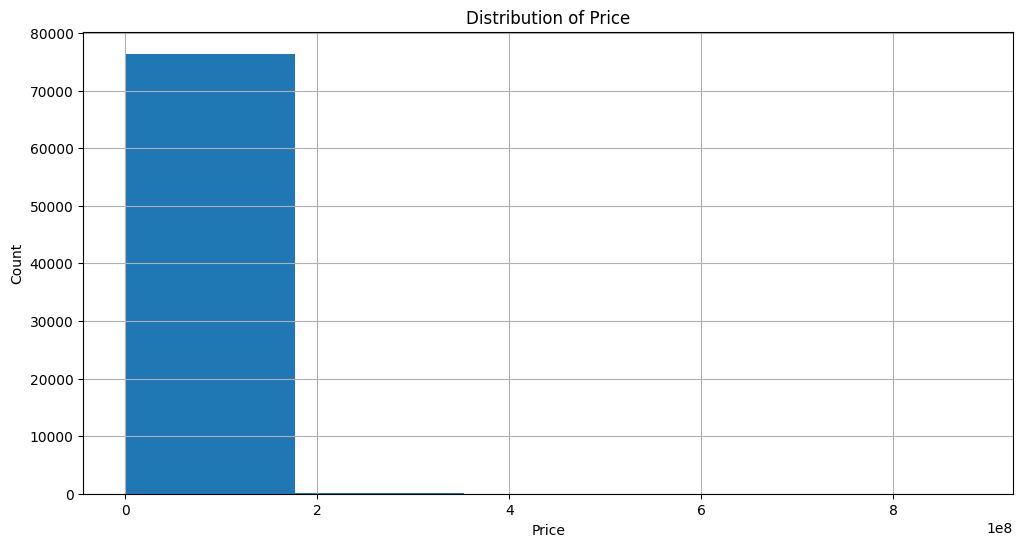

In [24]:
plt.figure(figsize=(12, 6))
df['price'].hist(bins=5)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of Price')
plt.show()

### This means the data is right skewed which is expected in real estate data as there are some very high priced properties that skew the distribution. We can consider log-transforming the price for certain analyses to mitigate this skewness.

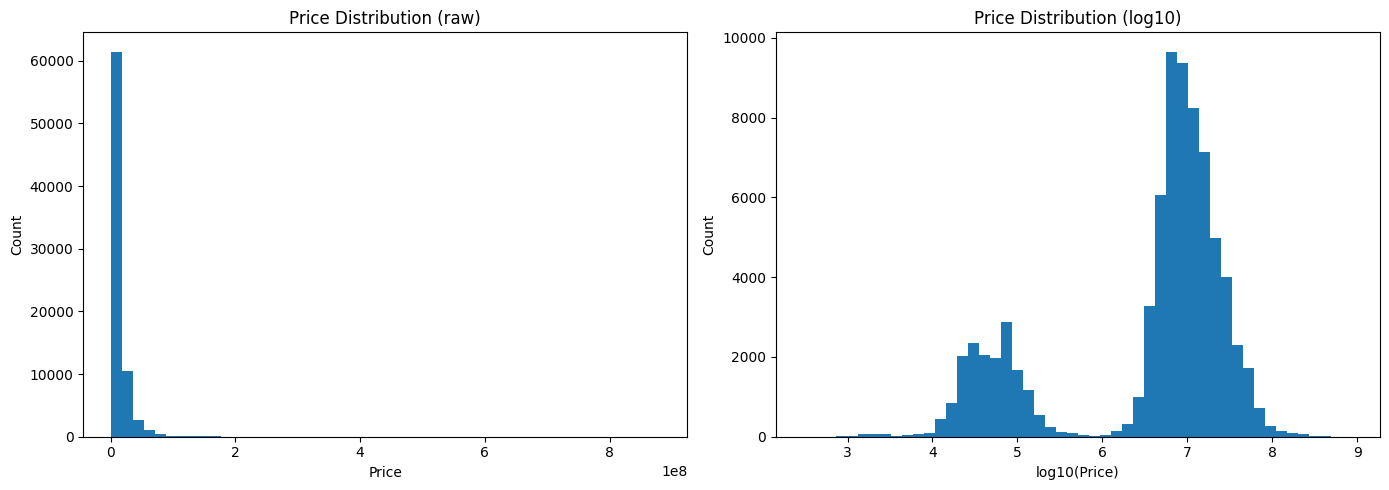

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw
axes[0].hist(df['price'].dropna(), bins=50)
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# log
axes[1].hist(np.log10(df['price'].dropna()), bins=50)
axes[1].set_title('Price Distribution (log10)')
axes[1].set_xlabel('log10(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
###

### This result is also expected as the data contain to different price models rental properties and sale properties. Each one of them will have to be treated differently 
### Now I'm going to draw a KDE plot to see the distribution of the price and see if there are any outliers

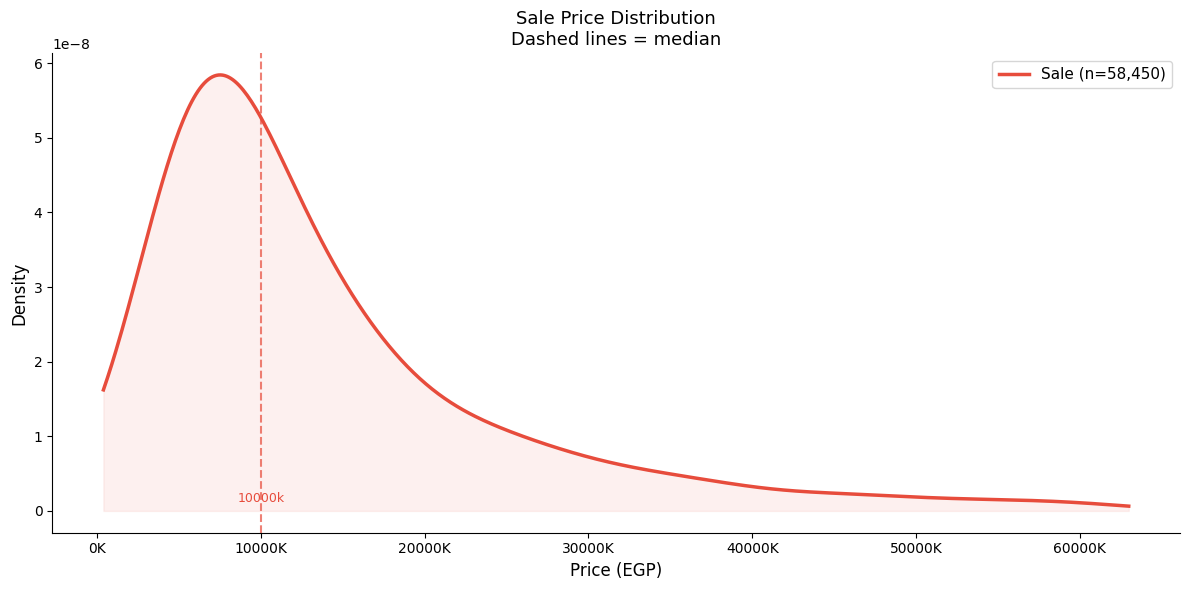

In [28]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))

price_data   = df['price'].dropna()
sale    = df[df['sale_or_rent'] == 'sale']['price'].dropna()

# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap_sale = df[df['sale_or_rent'] == 'sale']['price'].quantile(0.98)

sale = sale[sale <= cap_sale]

# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (sale, 'Sale', '#e74c3c')
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap_sale, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median()/1000:.0f}k', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Price (EGP)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Sale Price Distribution\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

### From this KDE I can interpert the following: 
1. The data is right skewed which is very reasnaoble in any realstate market.
2. The median is 10 million. I'm not surprised as the most of the data is newlly developed areas like new cairo and this is a very reasonable price there 
   

In [33]:
df['property_type'].value_counts()

property_type
apartments    55213
villas        21307
Name: count, dtype: Int64

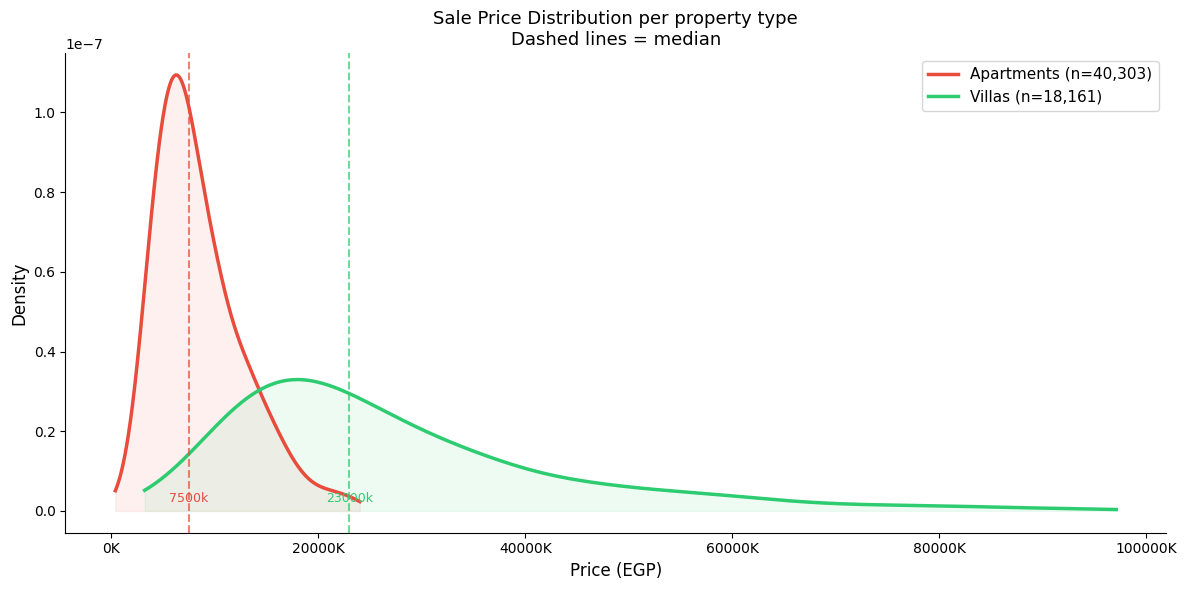

In [55]:
### Now let's see the difference between apartments and villas distribution 
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))

price_data   = df['price'].dropna()
apartment_sale = df[(df['sale_or_rent'] == 'sale' )&(df['property_type'] == 'apartments')]['price'].dropna()
villa_sale = df[(df['sale_or_rent'] == 'sale' )&(df['property_type'] == 'villas')]['price'].dropna()
# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap_app_sale = df[(df['sale_or_rent'] == 'sale' )& (df['property_type'] == 'apartments')]['price'].quantile(0.98)
cap_villa_sale = df[(df['sale_or_rent'] == 'sale' )& (df['property_type'] == 'villas')]['price'].quantile(0.98)

app_sale = apartment_sale[apartment_sale <= cap_app_sale]
villa_sale = villa_sale[villa_sale <= cap_villa_sale]
# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (app_sale, 'Apartments', '#e74c3c'),
    (villa_sale, 'Villas', '#2ecc71' )
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap_app_sale if 'Apartments' in label else cap_villa_sale, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median()/1000:.0f}k', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Price (EGP)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Sale Price Distribution per property type\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

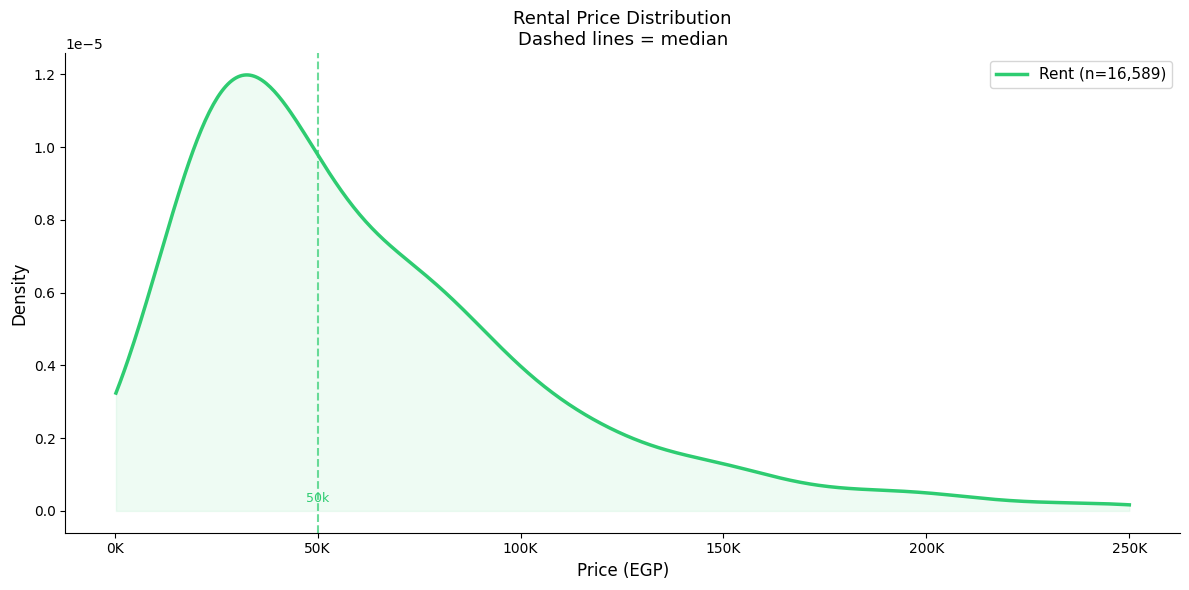

In [56]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))

price_data   = df['price'].dropna()
rent    = df[df['sale_or_rent'] == 'rent']['price'].dropna()

# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap_rent = df[df['sale_or_rent'] == 'rent']['price'].quantile(0.98)

rent = rent[rent <= cap_rent]

# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (rent, 'Rent', '#2ecc71')
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap_rent, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median()/1000:.0f}k', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Price (EGP)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Rental Price Distribution\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

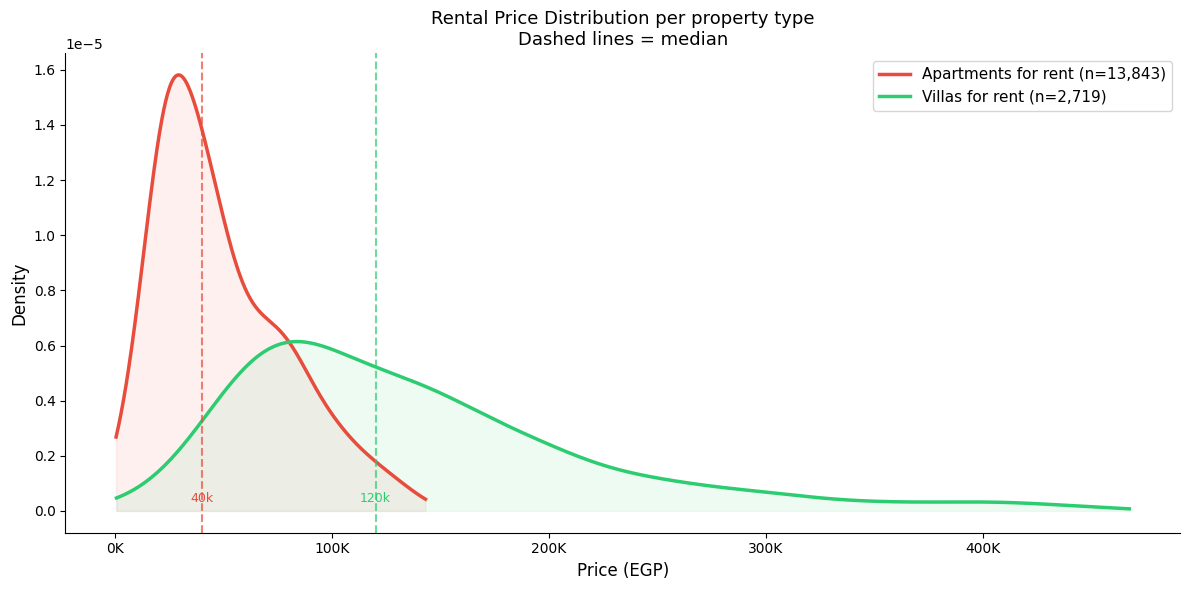

In [57]:
### Now let's see the difference between apartments and villas distribution 
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 6))

price_data   = df['price'].dropna()
apartment_sale = df[(df['sale_or_rent'] == 'rent' )&(df['property_type'] == 'apartments')]['price'].dropna()
villa_sale = df[(df['sale_or_rent'] == 'rent' )&(df['property_type'] == 'villas')]['price'].dropna()
# ── Optional: clip extreme outliers for cleaner KDE ──────────
cap_rent = df[df['sale_or_rent'] == 'rent']['price'].quantile(0.98)
cap_app_rent = df[(df['sale_or_rent'] == 'rent' )& (df['property_type'] == 'apartments')]['price'].quantile(0.98)
cap_villa_rent = df[(df['sale_or_rent'] == 'rent' )& (df['property_type'] == 'villas')]['price'].quantile(0.98)

app_sale = apartment_sale[apartment_sale <= cap_app_rent]
villa_sale = villa_sale[villa_sale <= cap_villa_rent]
# ── Plot KDE for each group ───────────────────────────────────
groups = [
    (app_sale, 'Apartments for rent', '#e74c3c'),
    (villa_sale, 'Villas for rent', '#2ecc71' )
]

for data, label, color in groups:
    kde = gaussian_kde(data, bw_method=0.3)
    x = np.linspace(data.min(), cap_app_rent if 'Apartments' in label else cap_villa_rent, 500)
    ax.plot(x, kde(x), label=f'{label} (n={len(data):,})', 
            color=color, linewidth=2.5)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

# ── Add median vertical lines ─────────────────────────────────
for data, label, color in groups:
    ax.axvline(data.median(), color=color, linestyle='--', 
               linewidth=1.5, alpha=0.7)
    ax.text(data.median(), ax.get_ylim()[1] * 0.02, 
            f'{data.median()/1000:.0f}k', 
            color=color, fontsize=9, ha='center')

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Price (EGP)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Rental Price Distribution per property type\n'
             'Dashed lines = median', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
# plt.savefig('rental_frequency_kde.png', dpi=150)
plt.show()

## From the Above KDE I can interpret the following:
1. The sale price of apartments with a sligh-right skewed with median 7.5 million but  some high luxury apartments drag the tail to the 25 million range.
2. Villa's sale price is highly right-skewed with very high variance ranging from (~ 6 million to 100+ million)
3. Apartment rentals are unimodal and concentrated tightly around a 40k EGP median but with a visible right skew — most of the market is predictable but there's a meaningful tail of higher-end rentals pulling the distribution right.

4. Villa rentals have a completely different shape — flat, wide, and heavily right-skewed with a median of 120k EGP — that's 3x the apartment median, and the tail stretches well past 400k, confirming these are two fundamentally different rental markets that absolutely need separate models.<br>
**Note**: **the *0.98* percintle is removed from all of those KDEs which means that all of this graphs doesn't contain extreme outlier values we look at those points in the *BOX-PLOT***




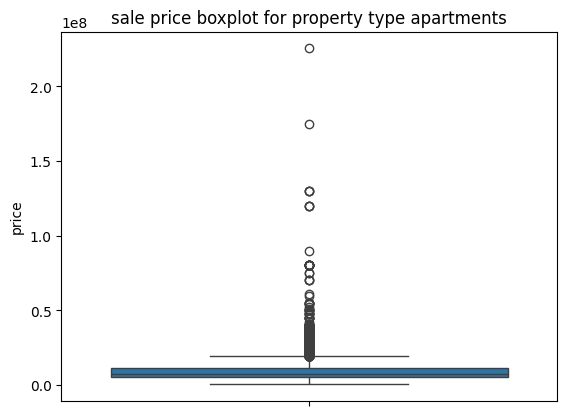

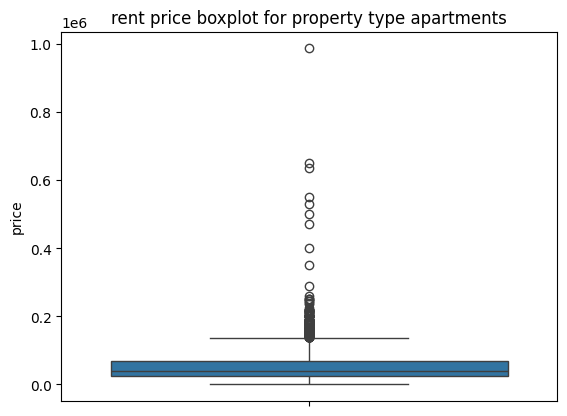

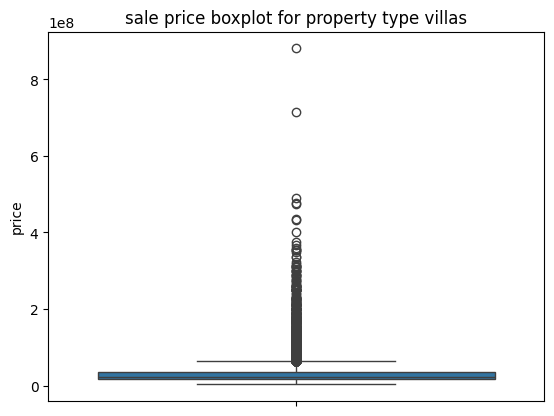

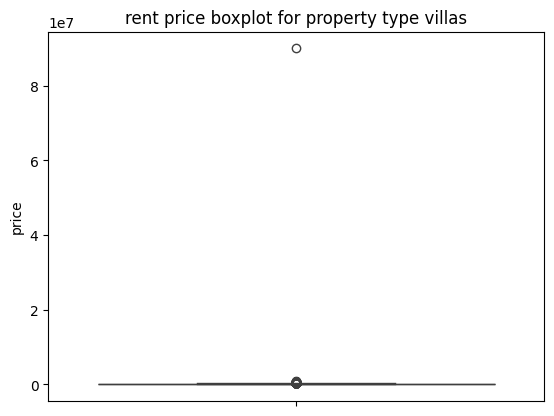

In [45]:
property_type = df['property_type'].unique()
sale_type = df['sale_or_rent'].unique()
for pro in property_type:
    for s in sale_type:
        price_data = df[(df['property_type'] == pro) & (df['sale_or_rent'] == s)]['price']
        sns.boxplot(price_data)
        plt.title(f'{s} price boxplot for property type {pro}')
        plt.show()

## Summarizing our findings for today: 
1. Price is heavily right-skewed with extreme outliers across all property types — expected in real estate and must be preserved, not suppressed, as high-value properties are a core market segment.
2. The skew pattern is consistent across property types, just at different price levels — suggesting the pricing mechanism is the same across segments.
3. ~14k listings are already sold. These are a valuable signal for understanding what sells fast — defined as the gap between when the listing link was scraped and when the content was actually collected.
4. Price follows a log-normal distribution, which makes sense given that real estate pricing is a multiplicative process (location × size × finishing × compound), not an additive one.

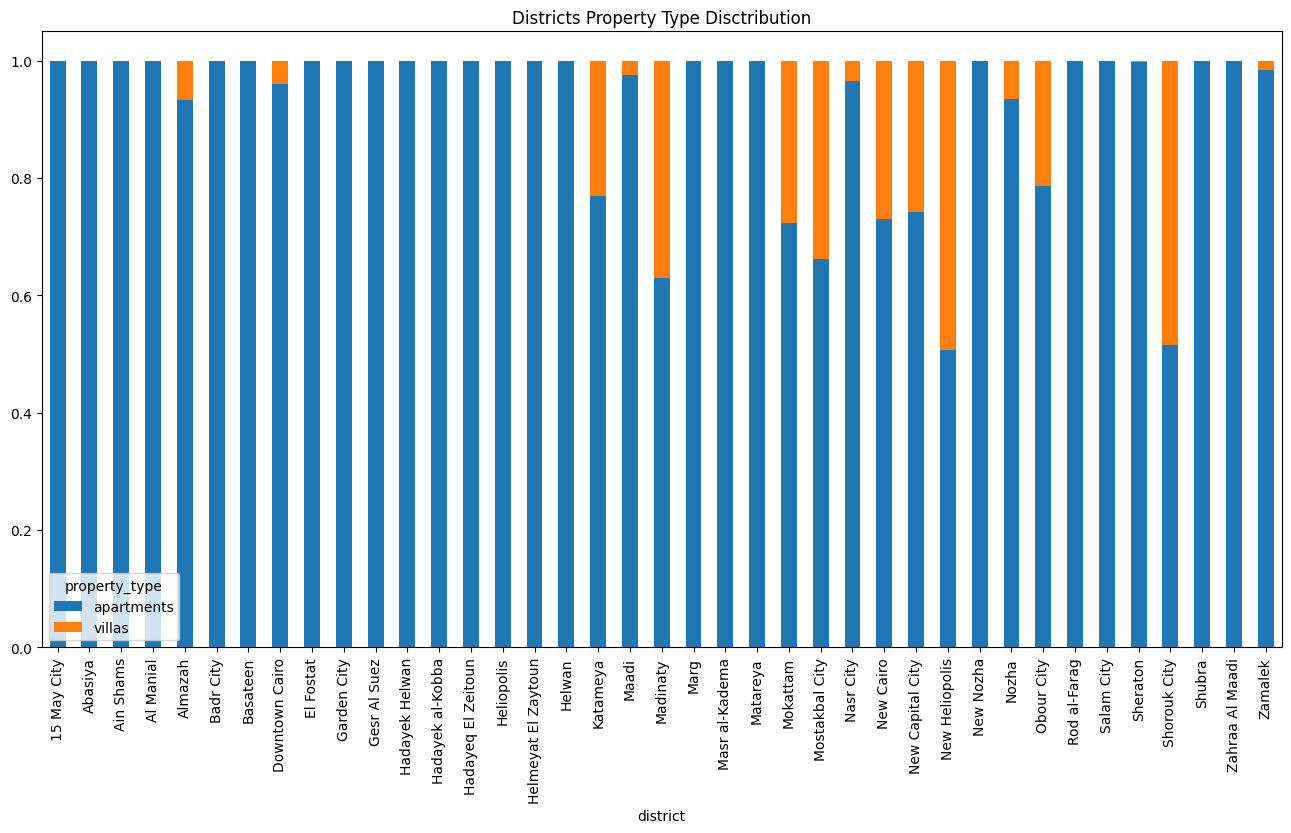

In [8]:
# First let's get an overview of what is the location distribution of our data district level 
# and in each district what are the domninat property type 
data = df.groupby('district')['property_type'].value_counts(normalize=True)
plot_df = data.unstack(level='property_type').fillna(0)
plot_df = plot_df.loc[(plot_df !=0).any(axis=1), (plot_df !=0).any(axis=0)]
plot_df.plot(kind='bar', stacked= True,figsize=(16,8))
plt.title('Districts Property Type Disctribution')
plt.show()

### From the above plot we can interpret the following:
1. The obvious the number of apartments is way more the number of villas 
2. New Heliopolis & Shrouk city contains the highest villas distribution compared to other district
3. Villas are only found in specific districts 

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76520 entries, 0 to 76519
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        76518 non-null  string        
 1   city                         76520 non-null  string        
 2   district                     76520 non-null  string        
 3   area                         69955 non-null  string        
 4   neighborhood                 40625 non-null  string        
 5   property_type                76520 non-null  string        
 6   sale_or_rent                 76520 non-null  string        
 7   price                        76520 non-null  Int64         
 8   seller_name                  76520 non-null  string        
 9   property_subtype             76520 non-null  string        
 10  bedrooms                     76520 non-null  Int64         
 11  bathrooms                    76520 non-nu

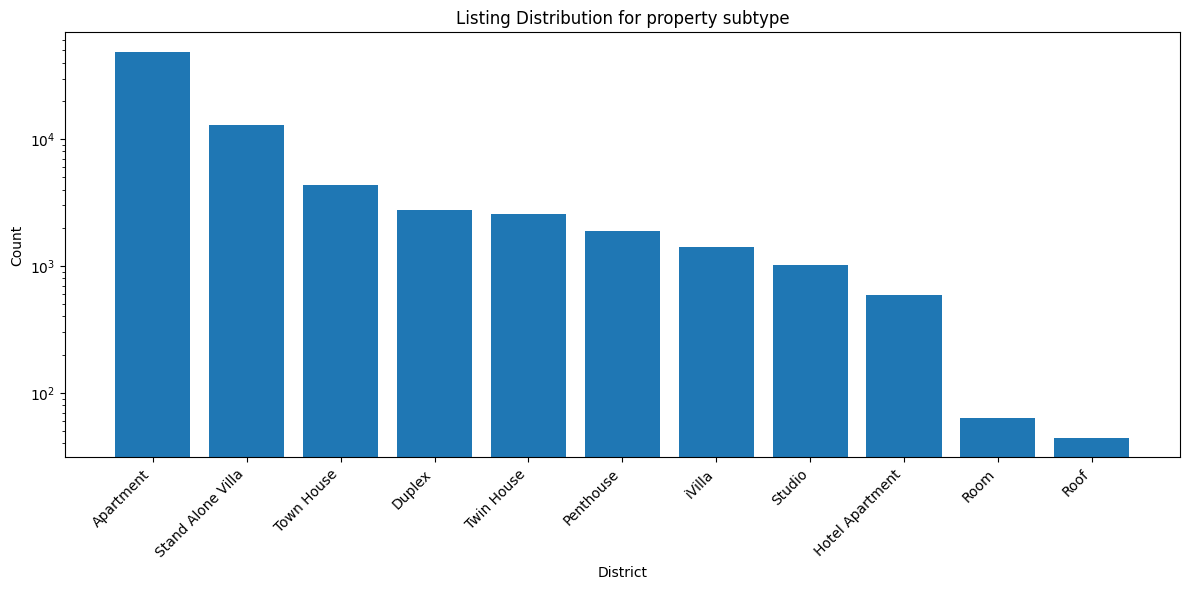

In [9]:
# First thing let's look at each variables individually understand them and build up from there 
# Let's start simply by district
counts = df['property_subtype'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(counts.index, counts.values)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.xlabel('District')
plt.ylabel('Count')
plt.title('Listing Distribution for property subtype')
plt.tight_layout()
plt.show()

In [11]:
df['bedrooms'].value_counts()

bedrooms
3     38905
2     15928
4     12052
5      4238
1      3332
6      1278
7       448
8       152
10      142
9        45
Name: count, dtype: Int64

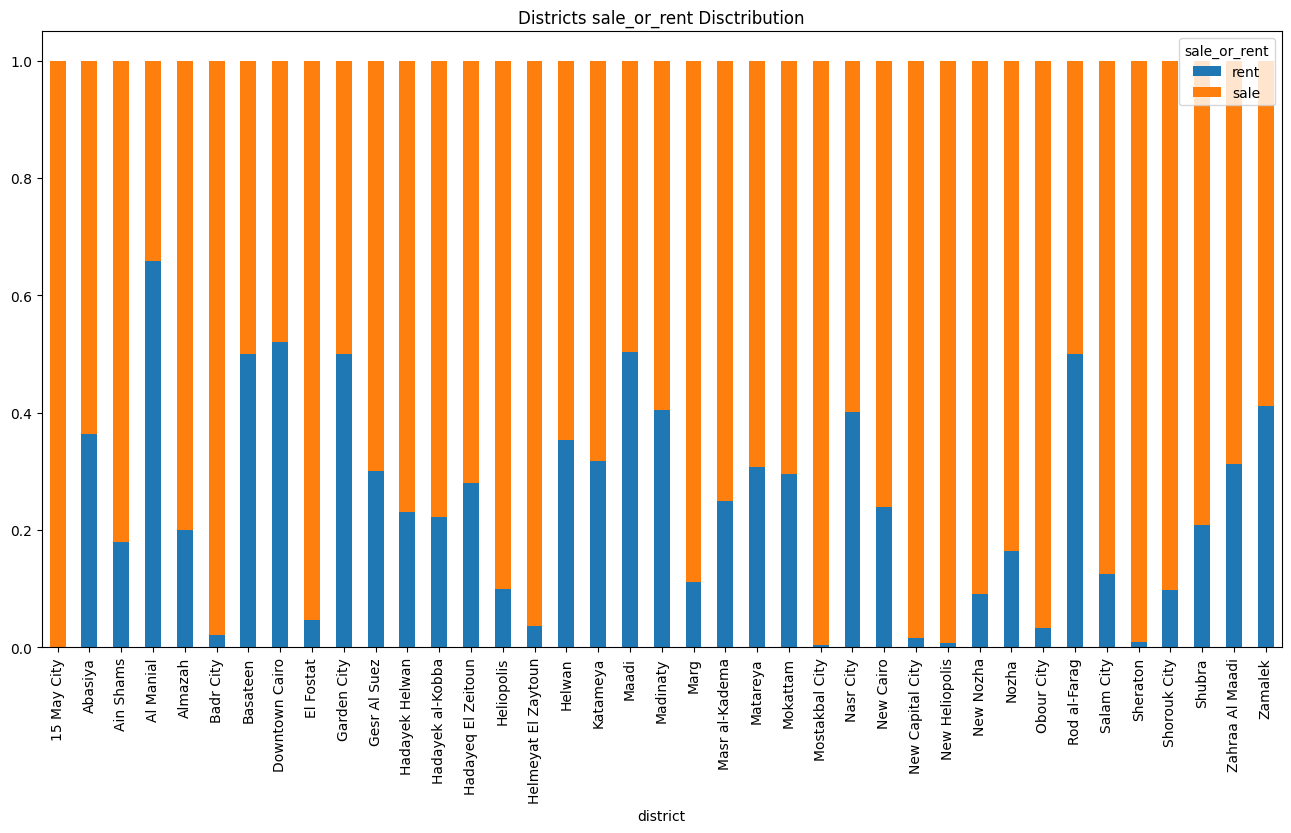

In [9]:
# First let's get an overview of what is the location distribution of our data district level 
# and in each district what are the domninat property type 
data = df.groupby('district')['sale_or_rent'].value_counts(normalize=True)
plot_df = data.unstack(level='sale_or_rent').fillna(0)
plot_df = plot_df.loc[(plot_df !=0).any(axis=1), (plot_df !=0).any(axis=0)]
plot_df.plot(kind='bar', stacked= True,figsize=(16,8))
plt.title('Districts sale_or_rent Disctribution')
plt.show()

In [ ]:
# What is interesting from this graph that in District Like al manial it contains more rental properties than on sale properties 
